# Statistical Analysis (Extended): Final Experiment — Does the Tail Help Reorientation?

**Goal:** Test if the tail (With Tail vs No Tail) affects reorientation performance in the final drop-test experiment.

**Data:** `report_final.csv`, produced by `data_analysis_final.py` from `telemetry/Final_Experiment/`. Fall-duration/distance filtering, the `0°-pitch`/`180°-roll` de-dup, and the spare-rep exclusion are already applied upstream — this notebook starts from the cleaned per-drop report.

**Problem:** Initial conditions (angles and velocities at release) vary randomly due to drop rig imprecision.

**Solution:** OLS regression controlling for trial condition and initial-condition variability (mirrors `stats_final.py`, expanded here for interactive exploration).

**Measurement:** Integrated front+rear body orientation (Section 1b) — front IMU and the FK-based rear-body reconstruction are combined by picking whichever segment is further from feet-down at the outcome frame ('worst_segment'), because front and rear diverge substantially at the outcome frame (mean gap ~8° roll, ~11° pitch; pitch correlation only 0.28 — verified live below) and "would the robot land on its feet" is a worst-case condition, not an averaging one (Section 1b). Front-only was the v1/v2 measurement; this version replaces it everywhere, not just as a side comparison.

**Conditions:** 3 roll magnitudes (`r45`, `r90`, `r180`) + 3 combined roll180+pitch conditions (`r180_p15`, `r180_p30`, `r180_p45`).

**Outcomes:** |Roll angle|, |Roll rate|, |Pitch angle|, |Pitch rate| at 2.5 m — absolute values, since deviation from upright in either direction is equally bad.

No cell outputs are pre-computed in this file — run all cells to populate plots/output.

**v2 note:** this is the extended version. Sections 1–10 are identical to `stats_final.ipynb` (load data, diagnostics, main model with HC3, corrected per-trial tests, precision-framed power) and were the **primary, pre-specified analysis**. Sections 11–16 are **exploratory / post-hoc**: they were written after looking at the Sections 1–10 results, to stress-test them from angles a reviewer would raise (residual assumptions, variance not just mean, equivalence framing, an outcome-definition check, an exclusion-rule audit) — not analyses that were planned in advance. That distinction matters for how much weight any single result there should carry, especially the one below that changes the picture rather than just reinforcing it (Section 15).

---


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Condition ordering used throughout (roll sweep, then pitch sweep) instead of alphabetical
ROLL_CONDITION_ORDER  = ['r45', 'r90', 'r180']
PITCH_CONDITION_ORDER = ['r180_p15', 'r180_p30', 'r180_p45']
CONDITION_ORDER       = ROLL_CONDITION_ORDER + PITCH_CONDITION_ORDER

MORPHOLOGIES = ['With Tail', 'No Tail']

# Bonferroni correction used in Section 6: the per-trial loop there tests all 4 outcomes
# (roll angle, roll rate, pitch angle, pitch rate) at each of the 6 trial conditions —
# 6 x 4 = 24 independent t-tests, so that's the correction factor (not the 3x2+3x2=12 pairing
# used in the older stats_mbc.py, which only tested each condition against its "native" outcome).
N_COMPARISONS = 24


## 1. Load Data and Create Variables

In [2]:
df = pd.read_csv('report_final.csv', dtype={'date': str})

print(f"Total drops: {len(df)}")
print(f"Morphologies: {df['morphology'].unique()}")
print(f"Trials: {df['trial'].unique()}")
print(f"\nDrops per morphology x trial:")
print(pd.crosstab(df['morphology'], df['trial'])[CONDITION_ORDER])


Total drops: 72
Morphologies: ['With Tail' 'No Tail']
Trials: ['r180' 'r45' 'r90' 'r180_p15' 'r180_p30' 'r180_p45']

Drops per morphology x trial:
trial       r45  r90  r180  r180_p15  r180_p30  r180_p45
morphology                                              
No Tail       6    7     6         6         6         6
With Tail     6    5     6         6         6         6


### 1b. Integrate Front + Rear Orientation

Front and rear body orientation differ substantially at the outcome frame — this is the reason the rest of the notebook doesn't just use the front IMU. Verified live below (mean gap, correlation), then combined via a swappable `integrate_orientation()` function, which is what every `abs_*_2p5m` / `*_initial` column from here on is actually built from.

**What question is this metric supposed to answer?** Not "what's the average orientation of the two segments" in the abstract — the actual question is **"would the robot land on its feet?"** That reframes what "combine" should mean.

**What "would it land on its feet" implies about how to combine front and rear:** the robot can only land stably if *both* ends are reasonably upright — one bad end is enough to prevent a stable landing regardless of how good the other end is. That's a worst-case (AND-type) condition, not an averaging (OR-type) one: averaging lets a bad segment be diluted by a good one, which understates exactly the failure mode that matters. So the default below, `'worst_segment'`, picks whichever of front/rear is *further* from feet-down at the outcome frame, and reports that segment's numbers — the failure that would actually determine whether the robot stands.

**A plain magnitude average is kept anyway, as a comparison, in Section 1c.** `(|front_deviation| + |rear_deviation|)/2` isn't a substitute for `worst_segment` — it still lets a bad segment be diluted by a good one, the wrong shape for "would it land on its feet" — but it's a legitimate, simple alternative worth showing side by side with the full statistical treatment (not just the headline coefficient). It can't be implemented as an `integrate_orientation()` method, because there's no single rotation that "is" the average of two deviation magnitudes — so it's computed separately, straight from the `F_`/`B_` columns already in `df`, not from `integrate_orientation()`.

In [3]:
def angular_distance(angle):
    '''Shortest angular distance from 0. Handles wrapped angles correctly.'''
    return np.abs(((angle + 180) % 360) - 180)

print(f"Mean |front-rear| roll gap:  {(angular_distance(df['F_roll_2p5m']) - angular_distance(df['B_roll_2p5m'])).abs().mean():.1f} deg")
print(f"Mean |front-rear| pitch gap: {(angular_distance(df['F_pitch_2p5m']) - angular_distance(df['B_pitch_2p5m'])).abs().mean():.1f} deg")
print(f"Front/rear roll correlation:  {angular_distance(df['F_roll_2p5m']).corr(angular_distance(df['B_roll_2p5m'])):.2f}")
print(f"Front/rear pitch correlation: {angular_distance(df['F_pitch_2p5m']).corr(angular_distance(df['B_pitch_2p5m'])):.2f}")


Mean |front-rear| roll gap:  7.8 deg
Mean |front-rear| pitch gap: 11.2 deg
Front/rear roll correlation:  0.67
Front/rear pitch correlation: 0.28


In [4]:
from scipy.spatial.transform import Rotation as R

def tilt_from_upright(rot):
    '''
    Angle between the body's local up axis (after rotation) and world-up -- the
    physically correct "is it feet-down" quantity. Unlike total rotation-from-identity
    (2*arccos|w|), this is invariant to yaw: spinning about the vertical axis doesn't
    affect whether you're upside-down, and shouldn't count against "standing on feet".
    Verified: identity -> 0 deg, 180 deg flip -> 180 deg, pure yaw -> 0 deg.
    '''
    return np.degrees(np.arccos(np.clip(rot.as_matrix()[..., 2, 2], -1, 1)))

def integrate_orientation(rot_front, rot_rear, method='worst_segment'):
    '''
    Combine front and rear body Rotation objects (scipy Rotation, one trajectory each,
    same length) into a single "whole robot" orientation trajectory. Swap `method` to
    try a different combination rule -- nothing else in this notebook needs to change,
    since every outcome column downstream is derived from whatever this returns.
    '''
    if method == 'front_only':
        return rot_front
    if method == 'rear_only':
        return rot_rear
    if method == 'worst_segment':
        # "Would it land on its feet?" is a worst-case condition -- one badly-oriented
        # segment is enough to prevent a stable landing, regardless of the other end.
        # Decide ONCE, at the outcome (final) frame, which segment is further from
        # feet-down, then use THAT segment's entire trajectory for angle and rate alike.
        # Deciding once (not per-frame) avoids a mid-trajectory switch that would show
        # up as a spurious velocity spike in the rate calculation.
        tilt_front_end = tilt_from_upright(rot_front[-1])
        tilt_rear_end  = tilt_from_upright(rot_rear[-1])
        return rot_front if tilt_front_end >= tilt_rear_end else rot_rear
    raise ValueError(f"Unknown integration method: {method!r}")

INTEGRATION_METHOD = 'worst_segment'  # <- swap this to try front_only / rear_only / a new method


In [5]:
# report_final.csv only stores the Euler-decomposed roll/pitch, not the raw quaternions, so
# getting the *rotation* objects back requires reloading the raw telemetry per trial (mirrors
# the per-file block in data_analysis_final.py, but keeps the full trajectory rather than just
# the endpoint, since rates need it too). Same fall-distance target, FK chain, and rate filter
# as the rest of the pipeline.
import os

BASE_DIR = '../../telemetry/Final_Experiment'
RATE_FILTER_CUTOFF_HZ = 15

def low_pass_filter(data, cutoff_freq, fs):
    from scipy.signal import butter, filtfilt
    b, a = butter(N=4, Wn=cutoff_freq / (0.5 * fs), btype='low', analog=False)
    return filtfilt(b, a, data, axis=0)

def quat_angvel_deg(rots, dt):
    angvel = np.zeros((len(dt), 3))
    for i in range(len(dt)):
        dq = rots[i].inv() * rots[i + 1]
        angvel[i] = np.degrees(dq.as_rotvec()) / dt[i]
    return angvel

def reconstruct_telemetry_path(morphology, trial, date, rep):
    '''Inverts data_analysis_final.py's file-discovery naming convention.'''
    prefix = morphology.replace(' ', '')  # 'With Tail' -> 'WithTail'
    if trial.startswith('r180_p'):
        sweep, ftype, deg = 'With Pitch', 'Pitch', trial.split('r180_p')[1]
    else:
        sweep, ftype, deg = 'No Pitch', 'Roll', trial[1:]
    fname = f'{prefix}{ftype}{deg}_{date}_{rep}.csv'
    return os.path.join(BASE_DIR, f'{morphology} {sweep}', f'{deg}deg', fname)

def load_front_rear_rotations(file_path):
    '''Front + FK-rear Rotation trajectories, same fall-distance target as everywhere else.'''
    raw = pd.read_csv(file_path)
    t0 = raw['Time'].iloc[0]
    t_target = np.sqrt(2 * 2.5 / 9.81) + t0
    end_idx = np.argmin(np.abs(raw['Time'] - t_target))
    time = raw['Time'].iloc[0:end_idx].to_numpy()

    f_rot = R.from_quat(raw[['F_Q0', 'F_Q1', 'F_Q2', 'F_Q3']].iloc[0:end_idx].to_numpy(), scalar_first=True)
    z = np.zeros(end_idx)
    r1 = R.from_rotvec(np.column_stack([raw['F_M1'].iloc[0:end_idx].to_numpy(), z, z]))
    rp = R.from_rotvec(np.column_stack([z, raw['F_M2'].iloc[0:end_idx].to_numpy(), z]))
    r2 = R.from_rotvec(np.column_stack([raw['B_M2'].iloc[0:end_idx].to_numpy(), z, z]))
    fk_rots = f_rot * r1 * rp * r2
    return time, f_rot, fk_rots

def process_trial_integrated(row, method=None):
    method = method or INTEGRATION_METHOD
    path = reconstruct_telemetry_path(row['morphology'], row['trial'], row['date'], row['rep'])
    time, f_rot, fk_rots = load_front_rear_rotations(path)

    integ_rots = integrate_orientation(f_rot, fk_rots, method=method)
    integ_ori = np.degrees(np.unwrap(np.radians(integ_rots.as_euler('xyz', degrees=True)), axis=0, discont=np.pi))

    # Same gimbal-lock sanity check as data_analysis_final.py, applied to the INTEGRATED
    # trajectory -- integration happens at the rotation level before Euler decomposition, so
    # it isn't corrupted by front's or rear's own individual gimbal-lock artifacts, but the
    # integrated result could in principle pass near gimbal lock on its own.
    max_abs_pitch = np.abs(integ_ori[:, 1]).max()
    gimbal_warning = max_abs_pitch > 80

    dt = np.diff(time)
    fs = 1 / np.median(dt)
    integ_angvel = low_pass_filter(quat_angvel_deg(integ_rots, dt), RATE_FILTER_CUTOFF_HZ, fs)

    return {
        'Integrated_roll_2p5m': integ_ori[-1, 0], 'Integrated_pitch_2p5m': integ_ori[-1, 1],
        'Integrated_roll_initial': integ_ori[0, 0], 'Integrated_pitch_initial': integ_ori[0, 1],
        'Integrated_rollrate_2p5m': integ_angvel[-1, 0], 'Integrated_pitchrate_2p5m': integ_angvel[-1, 1],
        'Integrated_rollrate_initial': integ_angvel[0, 0], 'Integrated_pitchrate_initial': integ_angvel[0, 1],
        'integrated_gimbal_warning': gimbal_warning, 'integrated_max_abs_pitch': max_abs_pitch,
    }

integrated_rows = [process_trial_integrated(row) for _, row in df.iterrows()]
integrated_df = pd.DataFrame(integrated_rows)
df = pd.concat([df.reset_index(drop=True), integrated_df], axis=1)

n_gimbal = df['integrated_gimbal_warning'].sum()
print(f"Reprocessed {len(df)} trials for the integrated trajectory (method='{INTEGRATION_METHOD}').")
print(f"Integrated-trajectory gimbal-lock warnings (|pitch| > 80°): {n_gimbal} "
      f"(worst: {df['integrated_max_abs_pitch'].max():.1f}°) "
      f"{'— none, good' if n_gimbal == 0 else '— CHECK THESE ROWS before trusting their integrated angle columns'}")


Reprocessed 72 trials for the integrated trajectory (method='worst_segment').
Integrated-trajectory gimbal-lock warnings (|pitch| > 80°): 1 (worst: 86.2°) — CHECK THESE ROWS before trusting their integrated angle columns


In [6]:
# Every abs_*_2p5m / *_initial name below is now built from the INTEGRATED (front+rear
# combined) orientation, not front-only -- Section 1b computed Integrated_roll_2p5m etc.
# above. F_*/B_* columns are untouched in df if you want to look at either body alone.
#
# IMPORTANT: F_roll/Integrated_roll values can exceed ±180° due to np.unwrap() in the
# processing pipeline. Taking abs() of 355° would give 355°, but physically that's only 5°
# from upright. We use shortest angular distance instead: wrap to [-180, 180], then abs().

def wrap_angle(angle):
    '''Wrap signed angle to [-180, 180].'''
    return ((angle + 180) % 360) - 180

# Outcomes: shortest angular distance from upright, computed on the INTEGRATED orientation
df['abs_roll_2p5m']      = angular_distance(df['Integrated_roll_2p5m'])
df['abs_pitch_2p5m']     = angular_distance(df['Integrated_pitch_2p5m'])
df['abs_rollrate_2p5m']  = df['Integrated_rollrate_2p5m'].abs()  # rates don't wrap
df['abs_pitchrate_2p5m'] = df['Integrated_pitchrate_2p5m'].abs()

# Initial conditions: wrap angles, keep rates signed -- also integrated, for consistency with
# the outcomes they're meant to control for (same body-orientation definition throughout).
df['roll_initial']      = wrap_angle(df['Integrated_roll_initial'])
df['pitch_initial']     = wrap_angle(df['Integrated_pitch_initial'])
df['rollrate_initial']  = df['Integrated_rollrate_initial']
df['pitchrate_initial'] = df['Integrated_pitchrate_initial']

print(f"Roll outcome range: [{df['abs_roll_2p5m'].min():.1f}, {df['abs_roll_2p5m'].max():.1f}] (should be ≤ 180)")
print(f"Pitch outcome range: [{df['abs_pitch_2p5m'].min():.1f}, {df['abs_pitch_2p5m'].max():.1f}] (should be ≤ 180)")
df[['morphology', 'trial', 'abs_roll_2p5m', 'abs_rollrate_2p5m', 'abs_pitch_2p5m', 'abs_pitchrate_2p5m']].head(10)


Roll outcome range: [0.6, 61.5] (should be ≤ 180)
Pitch outcome range: [0.5, 65.6] (should be ≤ 180)


,morphology,trial,abs_roll_2p5m,abs_rollrate_2p5m,abs_pitch_2p5m,abs_pitchrate_2p5m
0,With Tail,r180,12.707358,24.155547,35.236994,288.210635
1,With Tail,r180,0.592143,167.651306,18.523657,190.071998
2,With Tail,r180,35.598193,62.744447,0.657517,103.332580
3,With Tail,r180,19.959090,149.161403,10.651376,356.817785
4,With Tail,r180,19.307924,110.469246,10.581689,51.442145
5,With Tail,r180,6.835340,186.748303,26.036908,23.327505
6,With Tail,r45,6.355671,71.577994,9.164485,188.737907
7,With Tail,r45,5.127586,70.289459,5.425380,43.722112
8,With Tail,r45,14.336473,39.994165,19.836757,369.349451
9,With Tail,r45,18.518917,60.252119,0.902006,3.885673


### 1c. Compare `worst_segment` Against the Plain Average

`worst_segment` (used everywhere in this notebook from here on) vs. the plain magnitude average described above — computed directly from the `F_`/`B_` columns already in `df`, no reprocessing needed. Both get the same OLS spec run on them here purely for this comparison; the notebook's actual Section 4/5 models are still the `worst_segment`-based ones defined later.

In [7]:
df['avg_abs_roll_2p5m']      = (angular_distance(df['F_roll_2p5m']) + angular_distance(df['B_roll_2p5m'])) / 2
df['avg_abs_pitch_2p5m']     = (angular_distance(df['F_pitch_2p5m']) + angular_distance(df['B_pitch_2p5m'])) / 2
df['avg_abs_rollrate_2p5m']  = (df['F_rollrate_2p5m'].abs() + df['B_rollrate_2p5m'].abs()) / 2
df['avg_abs_pitchrate_2p5m'] = (df['F_pitchrate_2p5m'].abs() + df['B_pitchrate_2p5m'].abs()) / 2

_MORPH_TERM  = 'C(morphology, Treatment(reference="No Tail"))'
_MORPH_PARAM = f'{_MORPH_TERM}[T.With Tail]'
_base = (f"{_MORPH_TERM} + C(trial) + roll_initial + pitch_initial "
         "+ rollrate_initial + pitchrate_initial")

print(f"{'Outcome':12s} {'Variant':16s} {'Coef':>8s} {'95% CI':>18s} {'p':>8s}")
print('-' * 66)
for metric, label in [('roll', 'Roll Angle'), ('rollrate', 'Roll Rate'),
                       ('pitch', 'Pitch Angle'), ('pitchrate', 'Pitch Rate')]:
    for variant, prefix in [('worst_segment', ''), ('average', 'avg_')]:
        var = f'{prefix}abs_{metric}_2p5m'
        m = smf.ols(f"{var} ~ {_base}", data=df).fit()
        coef, p = m.params[_MORPH_PARAM], m.pvalues[_MORPH_PARAM]
        ci = m.conf_int().loc[_MORPH_PARAM]
        flag = ' ✅' if p < 0.05 else ''
        print(f"{label:12s} {variant:16s} {coef:+8.2f} [{ci[0]:7.2f},{ci[1]:7.2f}] {p:8.4f}{flag}")
    print()


Outcome      Variant              Coef             95% CI        p
------------------------------------------------------------------
Roll Angle   worst_segment       -5.15 [ -11.95,   1.66]   0.1354
Roll Angle   average             -4.47 [ -10.03,   1.10]   0.1136

Roll Rate    worst_segment      -51.19 [-103.38,   1.00]   0.0544
Roll Rate    average            -28.88 [ -75.52,  17.75]   0.2202

Pitch Angle  worst_segment       -5.59 [ -12.27,   1.08]   0.0991
Pitch Angle  average             -2.90 [  -7.90,   2.10]   0.2504

Pitch Rate   worst_segment      +15.92 [ -58.47,  90.31]   0.6702
Pitch Rate   average             -4.42 [ -66.93,  58.10]   0.8881



### 1d. Full Statistical Comparison: `worst_segment` vs. Average

Section 1c only compared the headline OLS coefficient. That's not the full picture -- everything Sections 6/11/12/13 do for `worst_segment` (per-trial breakdown, permutation test, variance/spread test, TOST) is repeated here for the plain average too, so "which outcome definition is right" isn't judged on a single number. Self-contained (doesn't reuse the Section 6/11/12/13 helper functions, since those aren't defined yet at this point in the notebook) and uses `n_perm=2000` rather than Section 11's `5000` to keep runtime reasonable for a secondary comparison -- less precise (~1% Monte Carlo error on the p-value instead of ~0.6%), fine for a comparison, not a substitute for Section 11's own `worst_segment` numbers.

In [8]:
_N_COMPARISONS_1D = 24  # matches Section 6's convention (6 conditions x 4 outcomes)
_variants = [('worst_segment', ''), ('average', 'avg_')]

print("Per-trial breakdown (Bonferroni-corrected t-test, alpha_adj = 0.05/24)")
print("=" * 100)
for metric, label in [('roll', 'Roll Angle'), ('rollrate', 'Roll Rate'),
                       ('pitch', 'Pitch Angle'), ('pitchrate', 'Pitch Rate')]:
    print(f"\n{label}")
    for variant, prefix in _variants:
        var = f'{prefix}abs_{metric}_2p5m'
        sig_conditions = []
        for cond in CONDITION_ORDER:
            dfc = df[df['trial'] == cond]
            a = dfc[dfc['morphology'] == 'With Tail'][var].dropna().values
            b = dfc[dfc['morphology'] == 'No Tail'][var].dropna().values
            if len(a) < 2 or len(b) < 2:
                continue
            _, p_t = stats.ttest_ind(a, b)
            if min(p_t * _N_COMPARISONS_1D, 1.0) < 0.05:
                sig_conditions.append(cond)
        print(f"  {variant:16s}: {len(sig_conditions)} of {len(CONDITION_ORDER)} conditions significant"
              f"{' (' + ', '.join(sig_conditions) + ')' if sig_conditions else ''}")


Per-trial breakdown (Bonferroni-corrected t-test, alpha_adj = 0.05/24)

Roll Angle
  worst_segment   : 0 of 6 conditions significant
  average         : 0 of 6 conditions significant

Roll Rate
  worst_segment   : 0 of 6 conditions significant
  average         : 0 of 6 conditions significant

Pitch Angle
  worst_segment   : 0 of 6 conditions significant
  average         : 0 of 6 conditions significant

Pitch Rate
  worst_segment   : 0 of 6 conditions significant
  average         : 0 of 6 conditions significant


In [9]:
def _permutation_test(var, n_perm=2000, seed=0):
    rng = np.random.default_rng(seed)
    formula = f"{var} ~ {_base}"
    observed = smf.ols(formula, data=df).fit().params[_MORPH_PARAM]
    df_perm = df.copy()
    null_coefs = np.empty(n_perm)
    for i in range(n_perm):
        df_perm['morphology'] = df.groupby('trial')['morphology'].transform(lambda s: rng.permutation(s.values))
        null_coefs[i] = smf.ols(formula, data=df_perm).fit().params[_MORPH_PARAM]
    p_perm = np.mean(np.abs(null_coefs) >= np.abs(observed))
    return observed, p_perm

print("Permutation test (n_perm=2000), parametric vs permutation p-value")
print("=" * 80)
for metric, label in [('roll', 'Roll Angle'), ('rollrate', 'Roll Rate'),
                       ('pitch', 'Pitch Angle'), ('pitchrate', 'Pitch Rate')]:
    for variant, prefix in _variants:
        var = f'{prefix}abs_{metric}_2p5m'
        m = smf.ols(f"{var} ~ {_base}", data=df).fit()
        p_param = m.pvalues[_MORPH_PARAM]
        _, p_perm = _permutation_test(var)
        print(f"  {label:12s} {variant:16s}: parametric p={p_param:.4f}   permutation p={p_perm:.4f}")
    print()


Permutation test (n_perm=2000), parametric vs permutation p-value
  Roll Angle   worst_segment   : parametric p=0.1354   permutation p=0.1440
  Roll Angle   average         : parametric p=0.1136   permutation p=0.1185

  Roll Rate    worst_segment   : parametric p=0.0544   permutation p=0.0510
  Roll Rate    average         : parametric p=0.2202   permutation p=0.2060

  Pitch Angle  worst_segment   : parametric p=0.0991   permutation p=0.0910
  Pitch Angle  average         : parametric p=0.2504   permutation p=0.2385

  Pitch Rate   worst_segment   : parametric p=0.6702   permutation p=0.6595
  Pitch Rate   average         : parametric p=0.8881   permutation p=0.8870



In [10]:
from scipy.stats import f as f_dist

_RESIDUALIZING_FORMULA = "{var} ~ C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"

def _variance_test(var, n_perm=2000, seed=0):
    m_blind = smf.ols(_RESIDUALIZING_FORMULA.format(var=var), data=df).fit()
    resid = m_blind.resid.values
    morph = df['morphology'].values
    trial = df['trial'].values
    a = resid[morph == 'With Tail']
    b = resid[morph == 'No Tail']
    F = b.var(ddof=1) / a.var(ddof=1)
    dfn, dfd = len(b) - 1, len(a) - 1
    p_naive = 2 * min(f_dist.cdf(F, dfn, dfd), 1 - f_dist.cdf(F, dfn, dfd))
    _, p_bf = stats.levene(a, b, center='median')
    rng = np.random.default_rng(seed)
    obs_ratio = F
    null_ratios = np.empty(n_perm)
    df_shuf = pd.DataFrame({'trial': trial, 'morphology': morph})
    for i in range(n_perm):
        perm_morph = df_shuf.groupby('trial')['morphology'].transform(lambda s: rng.permutation(s.values)).values
        pa, pb = resid[perm_morph == 'With Tail'], resid[perm_morph == 'No Tail']
        null_ratios[i] = pb.var(ddof=1) / pa.var(ddof=1)
    extremity = max(obs_ratio, 1 / obs_ratio)
    p_perm = np.mean((null_ratios >= extremity) | (null_ratios <= 1 / extremity))
    return F, p_naive, p_bf, p_perm

print("Variance-ratio tests on trial/covariate-adjusted residuals (n_perm=2000)")
print("=" * 100)
for metric, label in [('roll', 'Roll Angle'), ('rollrate', 'Roll Rate'),
                       ('pitch', 'Pitch Angle'), ('pitchrate', 'Pitch Rate')]:
    for variant, prefix in _variants:
        var = f'{prefix}abs_{metric}_2p5m'
        ratio, p_naive, p_bf, p_perm = _variance_test(var)
        sig = ' ✅' if (p_bf < 0.05 and p_perm < 0.05) else ''
        print(f"  {label:12s} {variant:16s}: ratio={ratio:.2f}  naiveF={p_naive:.4f}  "
              f"BrownForsythe={p_bf:.4f}  perm={p_perm:.4f}{sig}")
    print()


Variance-ratio tests on trial/covariate-adjusted residuals (n_perm=2000)
  Roll Angle   worst_segment   : ratio=1.60  naiveF=0.1704  BrownForsythe=0.3390  perm=0.3085
  Roll Angle   average         : ratio=1.63  naiveF=0.1576  BrownForsythe=0.4199  perm=0.4295

  Roll Rate    worst_segment   : ratio=2.54  naiveF=0.0076  BrownForsythe=0.0394  perm=0.0145 ✅
  Roll Rate    average         : ratio=1.89  naiveF=0.0646  BrownForsythe=0.4801  perm=0.4115

  Pitch Angle  worst_segment   : ratio=1.36  naiveF=0.3661  BrownForsythe=0.2553  perm=0.2875
  Pitch Angle  average         : ratio=1.28  naiveF=0.4715  BrownForsythe=0.4410  perm=0.4380

  Pitch Rate   worst_segment   : ratio=0.92  naiveF=0.7963  BrownForsythe=0.6407  perm=0.7880
  Pitch Rate   average         : ratio=1.17  naiveF=0.6508  BrownForsythe=0.8668  perm=0.5815



In [11]:
from scipy.stats import t as t_dist

def _tost(coef, se, dfres, delta, alpha=0.05):
    t1 = (coef - (-delta)) / se
    t2 = (coef - (delta)) / se
    p1 = 1 - t_dist.cdf(t1, dfres)
    p2 = t_dist.cdf(t2, dfres)
    p_tost = max(p1, p2)
    return p_tost, p_tost < alpha

_DELTA_ANGLE = {'small': 5, 'large': 10}
_DELTA_RATE  = {'small': 20, 'large': 40}

print("TOST equivalence test (placeholder bounds -- see Section 13 caveat, same applies here)")
print("=" * 90)
for metric, label, bounds in [('roll', 'Roll Angle', _DELTA_ANGLE), ('rollrate', 'Roll Rate', _DELTA_RATE),
                               ('pitch', 'Pitch Angle', _DELTA_ANGLE), ('pitchrate', 'Pitch Rate', _DELTA_RATE)]:
    for variant, prefix in _variants:
        var = f'{prefix}abs_{metric}_2p5m'
        m = smf.ols(f"{var} ~ {_base}", data=df).fit()
        coef, se, dfres = m.params[_MORPH_PARAM], m.bse[_MORPH_PARAM], m.df_resid
        results = []
        for bound_name, delta in bounds.items():
            p_tost, equiv = _tost(coef, se, dfres, delta)
            results.append(f"±{delta}={'✅' if equiv else 'no'}({p_tost:.3f})")
        print(f"  {label:12s} {variant:16s} coef={coef:+7.2f}: {'  '.join(results)}")
    print()


TOST equivalence test (placeholder bounds -- see Section 13 caveat, same applies here)
  Roll Angle   worst_segment    coef=  -5.15: ±5=no(0.517)  ±10=no(0.080)
  Roll Angle   average          coef=  -4.47: ±5=no(0.424)  ±10=✅(0.026)

  Roll Rate    worst_segment    coef= -51.19: ±20=no(0.882)  ±40=no(0.665)
  Roll Rate    average          coef= -28.88: ±20=no(0.648)  ±40=no(0.318)

  Pitch Angle  worst_segment    coef=  -5.59: ±5=no(0.570)  ±10=no(0.096)
  Pitch Angle  average          coef=  -2.90: ±5=no(0.202)  ±10=✅(0.003)

  Pitch Rate   worst_segment    coef= +15.92: ±20=no(0.457)  ±40=no(0.260)
  Pitch Rate   average          coef=  -4.42: ±20=no(0.310)  ±40=no(0.130)



**Takeaway from Section 1d (numbers from the last run):**

- **Per-trial breakdown**: identical for both methods — 0 of 6 conditions reach Bonferroni-corrected significance either way. No disagreement here.
- **Permutation test**: confirms the parametric p-value for both methods on all four outcomes (largest gap is Roll Rate worst_segment, 0.054 parametric vs 0.051 permutation) — neither method's result is a non-normality artifact.
- **Variance/spread — this is where the two methods disagree, and it matters.** `worst_segment`'s roll-rate variance finding (ratio=2.54, Brown-Forsythe p=0.039, permutation p=0.015 — both significant) does **not** replicate under the average (ratio=1.89, Brown-Forsythe p=0.48, permutation p=0.41 — nowhere close). That's a real disagreement, not noise, and it means the variance-reduction finding highlighted in Section 12/17 is specific to how `worst_segment` concentrates signal onto whichever segment is failing — it is not a property of the front+rear data that shows up regardless of how you combine them. Worth stating plainly: this makes the variance finding *more* method-dependent than the notebook's Section 17 discussion alone would suggest, not less.
- **TOST**: the average reaches equivalence within ±10° for roll angle (p=0.026) and pitch angle (p=0.003); `worst_segment` doesn't reach equivalence at any bound for any outcome. This isn't a contradiction — it's the direct consequence of the average having smaller, more tightly-estimated coefficients (closer to a genuine null) while `worst_segment` has larger coefficients with more uncertainty (consistent with carrying a real but unresolved effect, not a tightly-bounded null).

Net: the mean-effect story (Sections 4/5/11) is consistent across both methods in direction and doesn't reverse. The variance-effect story (Section 12) is not — it depends on which outcome definition you pick, and that dependency should be reported alongside the finding itself, not left implicit.

## 2. Diagnostic Checks: Confounds and Blocking

**Question A — within-condition imbalance:** does tail presence systematically affect initial conditions, controlling for trial?

**Method:** Two-way ANOVA: `Initial_Condition ~ Morphology + Trial`. p > 0.05 → no detectable imbalance; p < 0.05 → flagged.

Four non-significant tests is *absence of evidence*, not evidence of absence — treat "no detectable imbalance" as a weaker claim than "confirmed random," especially for any variable close to the 0.05 threshold. The model in Section 4 adjusts for these covariates regardless, so causal interpretation doesn't hinge entirely on this check passing.

**Question B — collection-date blocking:** the two morphologies were not collected in a randomized interleaved order — they're unevenly split across the three collection dates. If anything drifted day-to-day (battery, rig calibration, joint wear), it could load onto the morphology coefficient. This is checked directly below by adding `C(date)` to the model and seeing whether the tail coefficient moves.

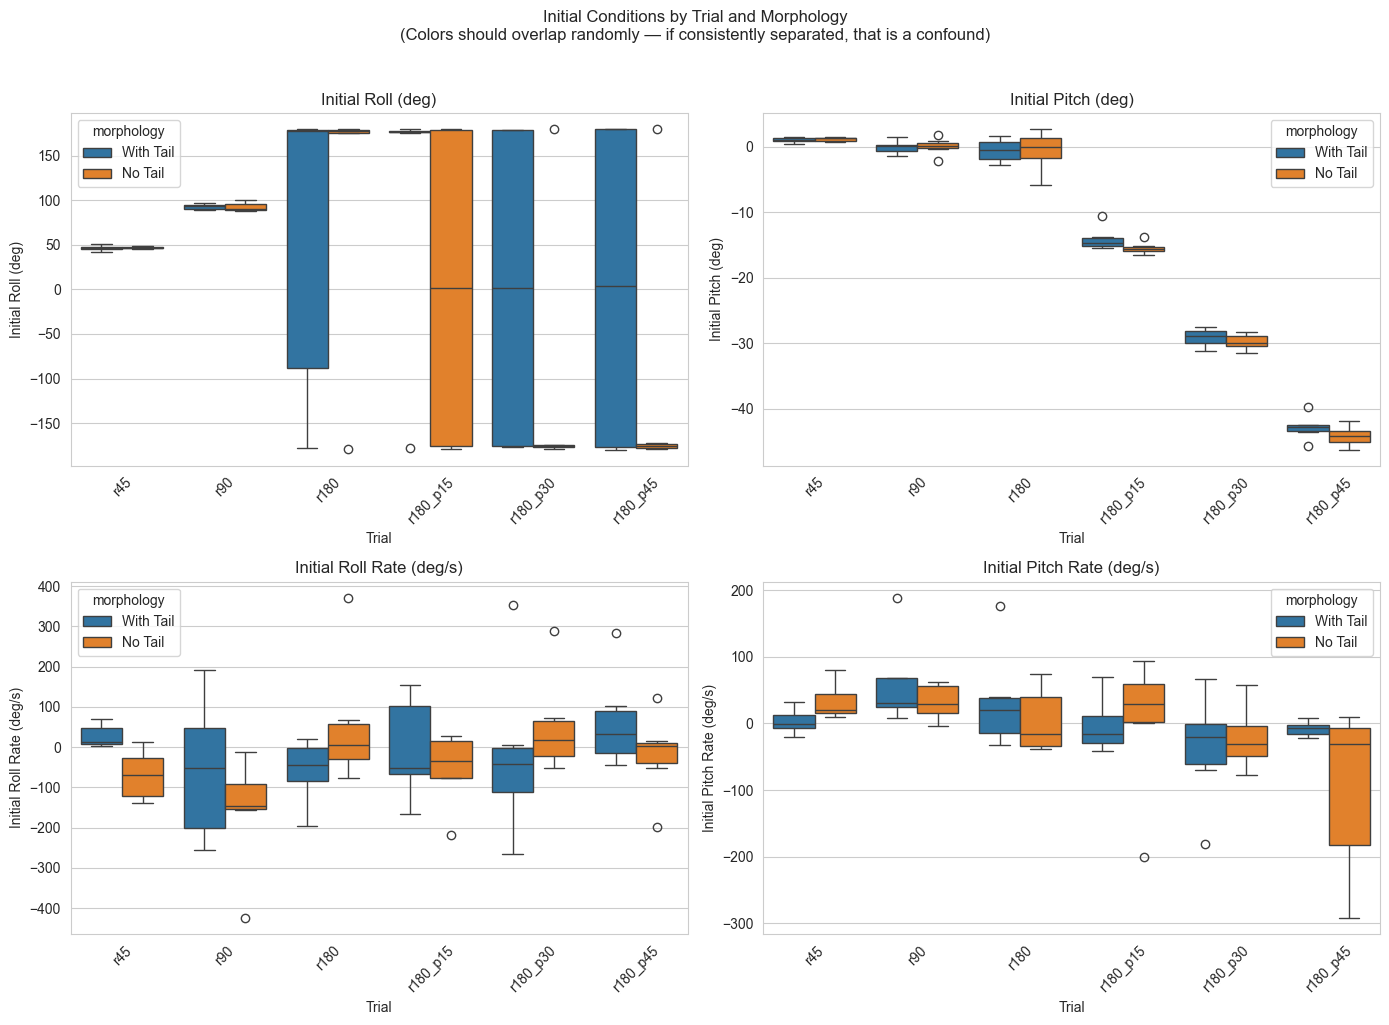

In [12]:
# Visualize initial conditions by trial and morphology
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

initial_vars = [
    ('roll_initial',      'Initial Roll (deg)'),
    ('pitch_initial',     'Initial Pitch (deg)'),
    ('rollrate_initial',  'Initial Roll Rate (deg/s)'),
    ('pitchrate_initial', 'Initial Pitch Rate (deg/s)')
]

for idx, (var, label) in enumerate(initial_vars):
    sns.boxplot(data=df, x='trial', y=var, hue='morphology', ax=axes[idx], order=CONDITION_ORDER)
    axes[idx].set_title(label)
    axes[idx].set_xlabel('Trial')
    axes[idx].set_ylabel(label)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Initial Conditions by Trial and Morphology\n(Colors should overlap randomly — if consistently separated, that is a confound)', y=1.02)
plt.tight_layout()
plt.show()


In [13]:
# Two-way ANOVA: Initial_Condition ~ Morphology + Trial
print("="*80)
print("DIAGNOSTIC A: Does tail presence affect initial conditions (controlling for trial)?")
print("="*80)

diagnostic_results = []
confound_flags = {}  # var -> bool, reused in Section 4/6 to flag caution on ANY outcome, not just the matched one

for var, label in initial_vars:
    model = smf.ols(f"{var} ~ C(morphology) + C(trial)", data=df).fit()
    anova_table = anova_lm(model, typ=2)

    morph_f = anova_table.loc['C(morphology)', 'F']
    morph_p = anova_table.loc['C(morphology)', 'PR(>F)']
    is_confounded = morph_p < 0.05
    result  = "✅ no detectable imbalance" if not is_confounded else "⚠️ CONFOUNDED"

    print(f"\n{label}")
    print(f"  Morphology effect: F = {morph_f:.3f}, p = {morph_p:.4f} → {result}")

    diagnostic_results.append({'Variable': label, 'F': morph_f, 'p-value': morph_p, 'Result': result})
    confound_flags[var] = is_confounded

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(pd.DataFrame(diagnostic_results).to_string(index=False))
print("\nNote: roll and pitch are mechanically coupled (Kane-Scher effect), so a confound in one")
print("initial variable can leak into an outcome it isn't nominally paired with. Section 4 checks")
print("outcome models against ALL flagged initial variables, not only the matching one.")


DIAGNOSTIC A: Does tail presence affect initial conditions (controlling for trial)?

Initial Roll (deg)
  Morphology effect: F = 2.267, p = 0.1370 → ✅ no detectable imbalance

Initial Pitch (deg)
  Morphology effect: F = 2.355, p = 0.1297 → ✅ no detectable imbalance

Initial Roll Rate (deg/s)
  Morphology effect: F = 0.559, p = 0.4575 → ✅ no detectable imbalance

Initial Pitch Rate (deg/s)
  Morphology effect: F = 1.055, p = 0.3081 → ✅ no detectable imbalance

SUMMARY
                  Variable        F  p-value                    Result
        Initial Roll (deg) 2.266556 0.137038 ✅ no detectable imbalance
       Initial Pitch (deg) 2.355475 0.129697 ✅ no detectable imbalance
 Initial Roll Rate (deg/s) 0.558621 0.457512 ✅ no detectable imbalance
Initial Pitch Rate (deg/s) 1.055464 0.308060 ✅ no detectable imbalance

Note: roll and pitch are mechanically coupled (Kane-Scher effect), so a confound in one
initial variable can leak into an outcome it isn't nominally paired with. Section 4

In [14]:
# DIAGNOSTIC B: collection-date blocking check
print("="*80)
print("DIAGNOSTIC B: Is morphology confounded with collection date?")
print("="*80)
print(pd.crosstab(df['date'], df['morphology']))
print()

MORPH_TERM  = 'C(morphology, Treatment(reference="No Tail"))'
MORPH_PARAM = f'{MORPH_TERM}[T.With Tail]'
FORMULA_BASE = f"{MORPH_TERM} + C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"

print("Sensitivity check: does adding C(date) move the tail coefficient?")
print("-" * 80)
for var, label in [('abs_roll_2p5m', '|Roll Angle|'), ('abs_rollrate_2p5m', '|Roll Rate|')]:
    m_base = smf.ols(f"{var} ~ {FORMULA_BASE}", data=df).fit()
    m_date = smf.ols(f"{var} ~ {FORMULA_BASE} + C(date)", data=df).fit()
    c_base, c_date = m_base.params[MORPH_PARAM], m_date.params[MORPH_PARAM]
    pct_change = (c_date - c_base) / abs(c_base) * 100

    ci_base = m_base.conf_int().loc[MORPH_PARAM]
    ci_date = m_date.conf_int().loc[MORPH_PARAM]
    ci_overlap = not (ci_date[1] < ci_base[0] or ci_date[0] > ci_base[1])

    print(f"{label}:")
    print(f"  without C(date): coef={c_base:+.2f}, 95% CI=[{ci_base[0]:.2f}, {ci_base[1]:.2f}], p={m_base.pvalues[MORPH_PARAM]:.4f}")
    print(f"  with C(date)   : coef={c_date:+.2f}, 95% CI=[{ci_date[0]:.2f}, {ci_date[1]:.2f}], p={m_date.pvalues[MORPH_PARAM]:.4f}")
    print(f"  → moved {pct_change:+.0f}% ({'same direction' if np.sign(c_base) == np.sign(c_date) else 'SIGN FLIPS — investigate'}, CIs {'overlap' if ci_overlap else 'do NOT overlap'})")
    print(f"  → date is doing real work in the model; this is a substantial adjustment, not confirmation of stability.")
print()
print("Caveat: C(date) is highly collinear with C(trial) here (the pitch sweep only ran on 08/17,")
print("r45/r90 only on 08/10 and 08/16), so no adjustment can cleanly separate 'date effect' from")
print("'trial effect' — this is a genuine design limitation (imbalanced blocking), not something")
print("this sensitivity check resolves. It belongs in the limitations section as a design flaw.")


DIAGNOSTIC B: Is morphology confounded with collection date?
morphology  No Tail  With Tail
date                          
0810              6          9
0816             10         20
0817             21          6

Sensitivity check: does adding C(date) move the tail coefficient?
--------------------------------------------------------------------------------
|Roll Angle|:
  without C(date): coef=-5.15, 95% CI=[-11.95, 1.66], p=0.1354
  with C(date)   : coef=-8.09, 95% CI=[-16.80, 0.62], p=0.0681
  → moved -57% (same direction, CIs overlap)
  → date is doing real work in the model; this is a substantial adjustment, not confirmation of stability.
|Roll Rate|:
  without C(date): coef=-51.19, 95% CI=[-103.38, 1.00], p=0.0544
  with C(date)   : coef=-77.63, 95% CI=[-143.90, -11.35], p=0.0225
  → moved -52% (same direction, CIs overlap)
  → date is doing real work in the model; this is a substantial adjustment, not confirmation of stability.

Caveat: C(date) is highly collinear with C(tri

## 3. Descriptive Statistics: Outcomes at 2.5m

In [15]:
outcomes = [
    ('abs_roll_2p5m',      '|Roll Angle| at 2.5m (deg)'),
    ('abs_rollrate_2p5m',  '|Roll Rate| at 2.5m (deg/s)'),
    ('abs_pitch_2p5m',     '|Pitch Angle| at 2.5m (deg)'),
    ('abs_pitchrate_2p5m', '|Pitch Rate| at 2.5m (deg/s)')
]

for var, label in outcomes:
    print(f"\n{label}:")
    print(df.groupby('morphology')[var].describe()[['mean', 'std', 'min', 'max', 'count']])



|Roll Angle| at 2.5m (deg):
                 mean        std       min        max  count
morphology                                                  
No Tail     20.893123  15.549855  1.351340  61.473865   37.0
With Tail   16.217141  11.701542  0.592143  52.902021   35.0

|Roll Rate| at 2.5m (deg/s):
                  mean         std        min         max  count
morphology                                                      
No Tail     152.503383  134.779872   0.251118  498.079651   37.0
With Tail   109.136460   73.436685  18.027642  353.299840   35.0

|Pitch Angle| at 2.5m (deg):
                 mean        std       min        max  count
morphology                                                  
No Tail     24.671179  15.956665  1.108062  65.573793   37.0
With Tail   16.896411  12.581866  0.528740  52.290492   35.0

|Pitch Rate| at 2.5m (deg/s):
                  mean         std       min         max  count
morphology                                                     
No T

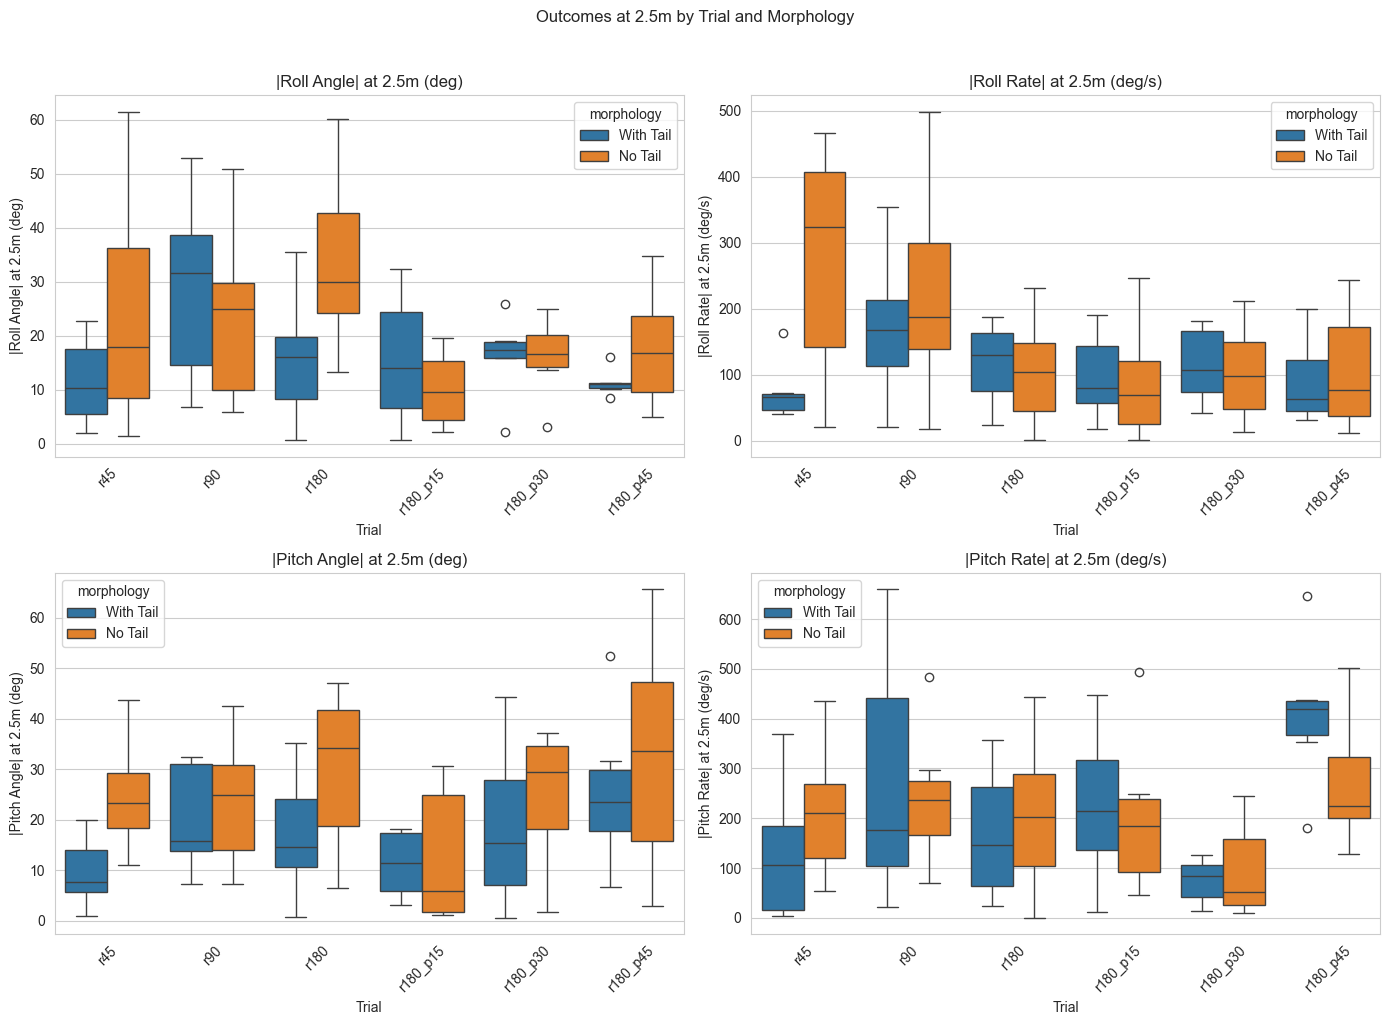

In [16]:
# Visualize outcomes by trial and morphology
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (var, label) in enumerate(outcomes):
    sns.boxplot(data=df, x='trial', y=var, hue='morphology', ax=axes[idx], order=CONDITION_ORDER)
    axes[idx].set_title(label)
    axes[idx].set_xlabel('Trial')
    axes[idx].set_ylabel(label)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Outcomes at 2.5m by Trial and Morphology', y=1.02)
plt.tight_layout()
plt.show()


## 4. Main Analysis: Linear Model

**Model:** `|Outcome| ~ Morphology + Trial + Initial_Roll + Initial_Pitch + Initial_RollRate + Initial_PitchRate`

- Controls for trial condition (intentional design) and initial condition noise (drop rig)
- `No Tail` is set as the reference level, so **the coefficient for `C(morphology, Treatment(reference="No Tail"))[T.With Tail]`** reads directly as "how much With Tail differs from No Tail" — positive = tail has *more* deviation (worse), negative = tail has *less* deviation (better)
- Reported alongside the standard (nonrobust) SEs are HC3 heteroscedasticity-robust SEs, since Section 8 finds non-normal, heteroscedastic residuals on 3 of 4 outcomes — if HC3 and nonrobust disagree substantially, trust HC3
- A condition-number warning shows up in some model summaries below (~6,000). This comes from `pitch_initial` being nearly collinear with the trial dummies — the three pitch conditions are *defined* by their initial pitch offset, so there's little within-condition variation left to separate the two. It inflates the *trial* coefficients' standard errors, not the morphology coefficient (which lives in a different, well-conditioned subspace); `stats_final_v2.ipynb` demonstrates this directly by re-fitting with within-trial-centered covariates, which reproduces an identical morphology coefficient at a much lower condition number.

In [17]:
def print_effect(model, label, matched_initial_var=None):
    coef = model.params[MORPH_PARAM]
    pval = model.pvalues[MORPH_PARAM]
    ci   = model.conf_int().loc[MORPH_PARAM]

    model_hc3 = smf.ols(model.model.formula, data=df).fit(cov_type='HC3')
    pval_hc3  = model_hc3.pvalues[MORPH_PARAM]

    print(f"Tail effect on {label}")
    print(f"  Coefficient        : {coef:+.2f} (With Tail vs No Tail)")
    print(f"  95% CI             : [{ci[0]:.2f}, {ci[1]:.2f}]")
    print(f"  p-value (nonrobust): {pval:.4f}")
    print(f"  p-value (HC3)      : {pval_hc3:.4f}")
    print(f"  R²                 : {model.rsquared:.3f}")
    print(f"  {'✅ SIGNIFICANT' if pval < 0.05 else '⚠️ NOT SIGNIFICANT'} (nonrobust); {'✅ SIGNIFICANT' if pval_hc3 < 0.05 else '⚠️ NOT SIGNIFICANT'} (HC3)")

    flagged = [v for v in confound_flags if confound_flags[v]]
    if flagged:
        matched_note = f" (matched: {matched_initial_var})" if matched_initial_var in flagged else ""
        print(f"  ⚠️ Confounded initial variable(s) in Diagnostic A: {flagged}{matched_note} — interpret with caution")


### 4.1 |Impact Roll Angle|

In [18]:
formula = f"abs_roll_2p5m ~ {FORMULA_BASE}"
model_roll_angle = smf.ols(formula, data=df).fit()
print(model_roll_angle.summary())


                            OLS Regression Results                            
Dep. Variable:          abs_roll_2p5m   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     1.170
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.328
Time:                        22:35:52   Log-Likelihood:                -284.93
No. Observations:                  72   AIC:                             591.9
Df Residuals:                      61   BIC:                             616.9
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [19]:
print_effect(model_roll_angle, '|Impact Roll Angle|', matched_initial_var='roll_initial')

Tail effect on |Impact Roll Angle|
  Coefficient        : -5.15 (With Tail vs No Tail)
  95% CI             : [-11.95, 1.66]
  p-value (nonrobust): 0.1354
  p-value (HC3)      : 0.1889
  R²                 : 0.161
  ⚠️ NOT SIGNIFICANT (nonrobust); ⚠️ NOT SIGNIFICANT (HC3)


### 4.2 |Impact Roll Rate|

In [20]:
formula = f"abs_rollrate_2p5m ~ {FORMULA_BASE}"
model_roll_rate = smf.ols(formula, data=df).fit()
print(model_roll_rate.summary())


                            OLS Regression Results                            
Dep. Variable:      abs_rollrate_2p5m   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     1.728
Date:                Tue, 18 Aug 2026   Prob (F-statistic):             0.0948
Time:                        22:35:52   Log-Likelihood:                -431.62
No. Observations:                  72   AIC:                             885.2
Df Residuals:                      61   BIC:                             910.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [21]:
print_effect(model_roll_rate, '|Impact Roll Rate|', matched_initial_var='rollrate_initial')

Tail effect on |Impact Roll Rate|
  Coefficient        : -51.19 (With Tail vs No Tail)
  95% CI             : [-103.38, 1.00]
  p-value (nonrobust): 0.0544
  p-value (HC3)      : 0.0639
  R²                 : 0.221
  ⚠️ NOT SIGNIFICANT (nonrobust); ⚠️ NOT SIGNIFICANT (HC3)


### 4.3 |Impact Pitch Angle|

In [22]:
formula = f"abs_pitch_2p5m ~ {FORMULA_BASE}"
model_pitch_angle = smf.ols(formula, data=df).fit()
print(model_pitch_angle.summary())


                            OLS Regression Results                            
Dep. Variable:         abs_pitch_2p5m   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     2.491
Date:                Tue, 18 Aug 2026   Prob (F-statistic):             0.0141
Time:                        22:35:52   Log-Likelihood:                -283.54
No. Observations:                  72   AIC:                             589.1
Df Residuals:                      61   BIC:                             614.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [23]:
print_effect(model_pitch_angle, '|Impact Pitch Angle|', matched_initial_var='pitch_initial')

Tail effect on |Impact Pitch Angle|
  Coefficient        : -5.59 (With Tail vs No Tail)
  95% CI             : [-12.27, 1.08]
  p-value (nonrobust): 0.0991
  p-value (HC3)      : 0.1496
  R²                 : 0.290
  ⚠️ NOT SIGNIFICANT (nonrobust); ⚠️ NOT SIGNIFICANT (HC3)


### 4.4 |Impact Pitch Rate|

In [24]:
formula = f"abs_pitchrate_2p5m ~ {FORMULA_BASE}"
model_pitch_rate = smf.ols(formula, data=df).fit()
print(model_pitch_rate.summary())


                            OLS Regression Results                            
Dep. Variable:     abs_pitchrate_2p5m   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     2.076
Date:                Tue, 18 Aug 2026   Prob (F-statistic):             0.0404
Time:                        22:35:52   Log-Likelihood:                -457.13
No. Observations:                  72   AIC:                             936.3
Df Residuals:                      61   BIC:                             961.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [25]:
print_effect(model_pitch_rate, '|Impact Pitch Rate|', matched_initial_var='pitchrate_initial')

Tail effect on |Impact Pitch Rate|
  Coefficient        : +15.92 (With Tail vs No Tail)
  95% CI             : [-58.47, 90.31]
  p-value (nonrobust): 0.6702
  p-value (HC3)      : 0.6949
  R²                 : 0.254
  ⚠️ NOT SIGNIFICANT (nonrobust); ⚠️ NOT SIGNIFICANT (HC3)


## 5. Summary of All Results

In [26]:
models = [
    (model_roll_angle,  '|Roll Angle| (deg)',   'roll_initial'),
    (model_roll_rate,   '|Roll Rate| (deg/s)',  'rollrate_initial'),
    (model_pitch_angle, '|Pitch Angle| (deg)',  'pitch_initial'),
    (model_pitch_rate,  '|Pitch Rate| (deg/s)', 'pitchrate_initial'),
]

results_summary = []
for model, outcome, matched_var in models:
    coef = model.params[MORPH_PARAM]
    pval = model.pvalues[MORPH_PARAM]
    ci   = model.conf_int().loc[MORPH_PARAM]

    # HC3 is the SE we said to trust in Section 4 (non-normal residuals) — the CI and significance
    # flag we lead with below should come from the same fit, not the nonrobust one.
    model_hc3 = smf.ols(model.model.formula, data=df).fit(cov_type='HC3')
    ci_hc3    = model_hc3.conf_int().loc[MORPH_PARAM]
    pval_hc3  = model_hc3.pvalues[MORPH_PARAM]

    sig  = '✅' if pval_hc3 < 0.05 else '⚠️'
    flagged = [v for v in confound_flags if confound_flags[v]]
    note = f'(caution: {", ".join(flagged)} confounded)' if flagged else ''
    results_summary.append({
        'Outcome': outcome,
        'Coef': f"{coef:+.2f}",
        '95% CI (nonrobust)': f"[{ci[0]:.2f}, {ci[1]:.2f}]",
        '95% CI (HC3)': f"[{ci_hc3[0]:.2f}, {ci_hc3[1]:.2f}]",
        'p-value (nonrobust)': f"{pval:.4f}",
        'p-value (HC3)': f"{pval_hc3:.4f}",
        'Sig': sig,
        'R²': f"{model.rsquared:.3f}",
        'Note': note
    })

print("="*110)
print("SUMMARY: Tail Effects (With Tail vs No Tail)")
print("Controlling for: Trial condition + Initial conditions | Integrated front+rear orientation | Absolute values")
print("="*110)
print(pd.DataFrame(results_summary).to_string(index=False))
print("\nNegative coefficient = With Tail has lower absolute deviation than No Tail (tail helps)")
print("Positive coefficient = With Tail has higher absolute deviation than No Tail (tail hurts)")

roll_angle_row = results_summary[0]  # |Roll Angle| (deg)
print(f"\nRead the HC3 CIs, not just the p-values — that's the SE we're trusting given the non-normal")
print(f"residuals. E.g. roll angle's HC3 CI is {roll_angle_row['95% CI (HC3)']} (nonrobust was")
print(f"{roll_angle_row['95% CI (nonrobust)']}): consistent with a tail benefit inside that range,")
print(f"and rules out a tail HARM larger than the CI's upper bound.")


SUMMARY: Tail Effects (With Tail vs No Tail)
Controlling for: Trial condition + Initial conditions | Integrated front+rear orientation | Absolute values
             Outcome   Coef 95% CI (nonrobust)    95% CI (HC3) p-value (nonrobust) p-value (HC3) Sig    R² Note
  |Roll Angle| (deg)  -5.15     [-11.95, 1.66]  [-12.83, 2.53]              0.1354        0.1889  ⚠️ 0.161     
 |Roll Rate| (deg/s) -51.19    [-103.38, 1.00] [-105.34, 2.96]              0.0544        0.0639  ⚠️ 0.221     
 |Pitch Angle| (deg)  -5.59     [-12.27, 1.08]  [-13.20, 2.01]              0.0991        0.1496  ⚠️ 0.290     
|Pitch Rate| (deg/s) +15.92    [-58.47, 90.31] [-63.64, 95.48]              0.6702        0.6949  ⚠️ 0.254     

Negative coefficient = With Tail has lower absolute deviation than No Tail (tail helps)
Positive coefficient = With Tail has higher absolute deviation than No Tail (tail hurts)

Read the HC3 CIs, not just the p-values — that's the SE we're trusting given the non-normal
residuals. E.g. 

## 6. Per-Trial Analysis

The overall analysis pools trials and may wash out effects that only show up in specific conditions — but running 6 conditions × 2 tests (t-test + MWU) × 4 outcomes is 48 comparisons, and at N≈5–7 per group per trial each individual test is very low powered. Two complementary ways to handle this:

1. **Formal interaction test**: does the tail's effect actually differ across trial conditions? A `morphology × trial` interaction term in the main model tests this directly, with much better power than 6 separate n≈6 comparisons.
2. **Per-trial t-tests, Bonferroni-corrected**: for exploratory/descriptive purposes, shown below with `α_adjusted = 0.05 / 12` (matching `stats_final.py`) rather than raw p-values — the version that gets plotted with significance markers.

> ⚠️ **Low power either way:** N≈5–7 per group per trial. Non-significance ≠ no effect.

In [27]:
# Formal test: does the tail effect vary by trial condition?
# Bonferroni-corrected across the 4 outcomes, since we're running this test 4 times.
print("Interaction test: morphology × trial (Bonferroni-corrected across 4 outcomes)")
print("=" * 80)

interaction_ps = {}
for var, label in outcomes:
    formula_int = f"{var} ~ {MORPH_TERM} * C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"
    m_int = smf.ols(formula_int, data=df).fit()
    anova_int = anova_lm(m_int, typ=2)
    int_rows = [r for r in anova_int.index if ':' in r]
    p_int = anova_int.loc[int_rows[0], 'PR(>F)'] if int_rows else np.nan
    p_int_adj = min(p_int * len(outcomes), 1.0)
    interaction_ps[label] = (p_int, p_int_adj)
    sig_raw = '✅ (raw)' if p_int < 0.05 else ''
    sig_adj = '✅ (Bonferroni)' if p_int_adj < 0.05 else ''
    print(f"  {label:30s}: raw p = {p_int:.4f} {sig_raw:15s} adjusted p = {p_int_adj:.4f} {sig_adj}")
    print(f"    (model fits {len(m_int.params)} params on {int(m_int.df_resid)} residual df, n={int(m_int.nobs)})")

any_raw_sig = any(p < 0.05 for p, _ in interaction_ps.values())
any_adj_sig = any(p_adj < 0.05 for _, p_adj in interaction_ps.values())

print()
if any_raw_sig and not any_adj_sig:
    flagged = [l for l, (p, _) in interaction_ps.items() if p < 0.05]
    print(f"⚠️→✅ {flagged} crossed the raw p<0.05 threshold but NOT the Bonferroni-adjusted one.")
    print("  With 4 tests run, one crossing raw 0.05 by chance is close to the expected false-positive")
    print("  rate — treat it as noise rather than a real trial-specific tail effect, especially given")
    print("  the interaction model's parameter count relative to residual df (see counts above).")
elif any_adj_sig:
    print("⚠️ At least one interaction survives Bonferroni correction — the tail effect genuinely")
    print("  differs by trial condition here. Pooling into a single overall coefficient (Section 5)")
    print("  would misrepresent that outcome; report it per-trial instead.")
else:
    print("✅ No interaction reaches even the raw 0.05 threshold — pooling trials into the overall")
    print("  Section 5 coefficient is well supported as the better-powered summary.")


Interaction test: morphology × trial (Bonferroni-corrected across 4 outcomes)
  |Roll Angle| at 2.5m (deg)    : raw p = 0.1988                 adjusted p = 0.7952 
    (model fits 16 params on 56 residual df, n=72)
  |Roll Rate| at 2.5m (deg/s)   : raw p = 0.1139                 adjusted p = 0.4555 
    (model fits 16 params on 56 residual df, n=72)
  |Pitch Angle| at 2.5m (deg)   : raw p = 0.3949                 adjusted p = 1.0000 
    (model fits 16 params on 56 residual df, n=72)
  |Pitch Rate| at 2.5m (deg/s)  : raw p = 0.4411                 adjusted p = 1.0000 
    (model fits 16 params on 56 residual df, n=72)

✅ No interaction reaches even the raw 0.05 threshold — pooling trials into the overall
  Section 5 coefficient is well supported as the better-powered summary.


In [28]:
ALPHA_CORRECTED = 0.05 / N_COMPARISONS

per_trial_results = []
for trial in CONDITION_ORDER:
    dft = df[df['trial'] == trial]
    row = {'Trial': trial}
    for var, label in outcomes:
        a = dft[dft['morphology'] == 'With Tail'][var]
        b = dft[dft['morphology'] == 'No Tail'][var]
        diff = a.mean() - b.mean()  # With Tail minus No Tail
        _, p_t = stats.ttest_ind(a, b)
        _, p_u = stats.mannwhitneyu(a, b, alternative='two-sided')
        p_t_adj = min(p_t * N_COMPARISONS, 1.0)
        row[f'{label} diff']       = round(diff, 1)
        row[f'{label} t p_adj']    = f"{p_t_adj:.3f}{'  ✅' if p_t_adj < 0.05 else ''}"
        row[f'{label} MWU p_raw']  = f"{p_u:.3f}"
    per_trial_results.append(row)

per_trial_df = pd.DataFrame(per_trial_results).set_index('Trial')

print('=' * 110)
print('PER-TRIAL TAIL EFFECTS (With Tail vs No Tail)')
print(f'Bonferroni-corrected t-test (alpha_adj={ALPHA_CORRECTED:.4f}) + raw Mann-Whitney U | N≈5-7/group/trial')
print('=' * 110)
print(per_trial_df.to_string())
print('\n✅ = p_adj < 0.05 | Positive diff = With Tail has more deviation')


PER-TRIAL TAIL EFFECTS (With Tail vs No Tail)
Bonferroni-corrected t-test (alpha_adj=0.0021) + raw Mann-Whitney U | N≈5-7/group/trial
          |Roll Angle| at 2.5m (deg) diff |Roll Angle| at 2.5m (deg) t p_adj |Roll Angle| at 2.5m (deg) MWU p_raw  |Roll Rate| at 2.5m (deg/s) diff |Roll Rate| at 2.5m (deg/s) t p_adj |Roll Rate| at 2.5m (deg/s) MWU p_raw  |Pitch Angle| at 2.5m (deg) diff |Pitch Angle| at 2.5m (deg) t p_adj |Pitch Angle| at 2.5m (deg) MWU p_raw  |Pitch Rate| at 2.5m (deg/s) diff |Pitch Rate| at 2.5m (deg/s) t p_adj |Pitch Rate| at 2.5m (deg/s) MWU p_raw
Trial                                                                                                                                                                                                                                                                                                                                                                                                                                    

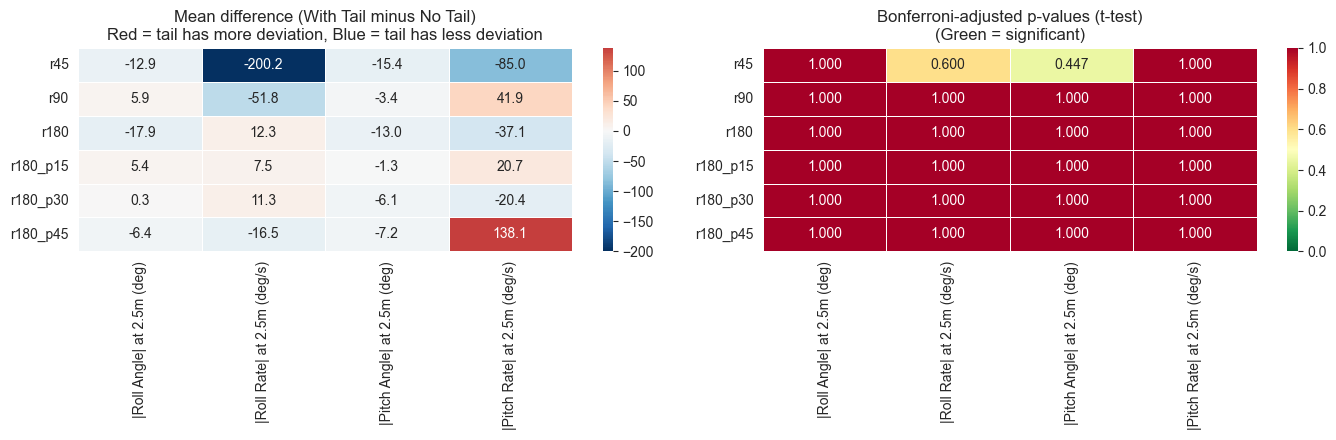

In [29]:
# Heatmaps: mean difference and Bonferroni-adjusted p-values
diff_data, pval_data = [], []
for trial in CONDITION_ORDER:
    dft = df[df['trial'] == trial]
    diff_row, pval_row = [], []
    for var, _ in outcomes:
        a = dft[dft['morphology'] == 'With Tail'][var]
        b = dft[dft['morphology'] == 'No Tail'][var]
        diff_row.append(a.mean() - b.mean())
        _, p = stats.ttest_ind(a, b)
        pval_row.append(min(p * N_COMPARISONS, 1.0))
    diff_data.append(diff_row); pval_data.append(pval_row)

col_labels = [l for _, l in outcomes]
diff_df = pd.DataFrame(diff_data, index=CONDITION_ORDER, columns=col_labels)
pval_df = pd.DataFrame(pval_data, index=CONDITION_ORDER, columns=col_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(diff_df, annot=True, fmt='.1f', center=0, cmap='RdBu_r', ax=axes[0], linewidths=0.5)
axes[0].set_title('Mean difference (With Tail minus No Tail)\nRed = tail has more deviation, Blue = tail has less deviation')
sns.heatmap(pval_df, annot=True, fmt='.3f', vmin=0, vmax=1.0, cmap='RdYlGn_r', ax=axes[1], linewidths=0.5)
axes[1].set_title('Bonferroni-adjusted p-values (t-test)\n(Green = significant)')
plt.tight_layout()
plt.show()


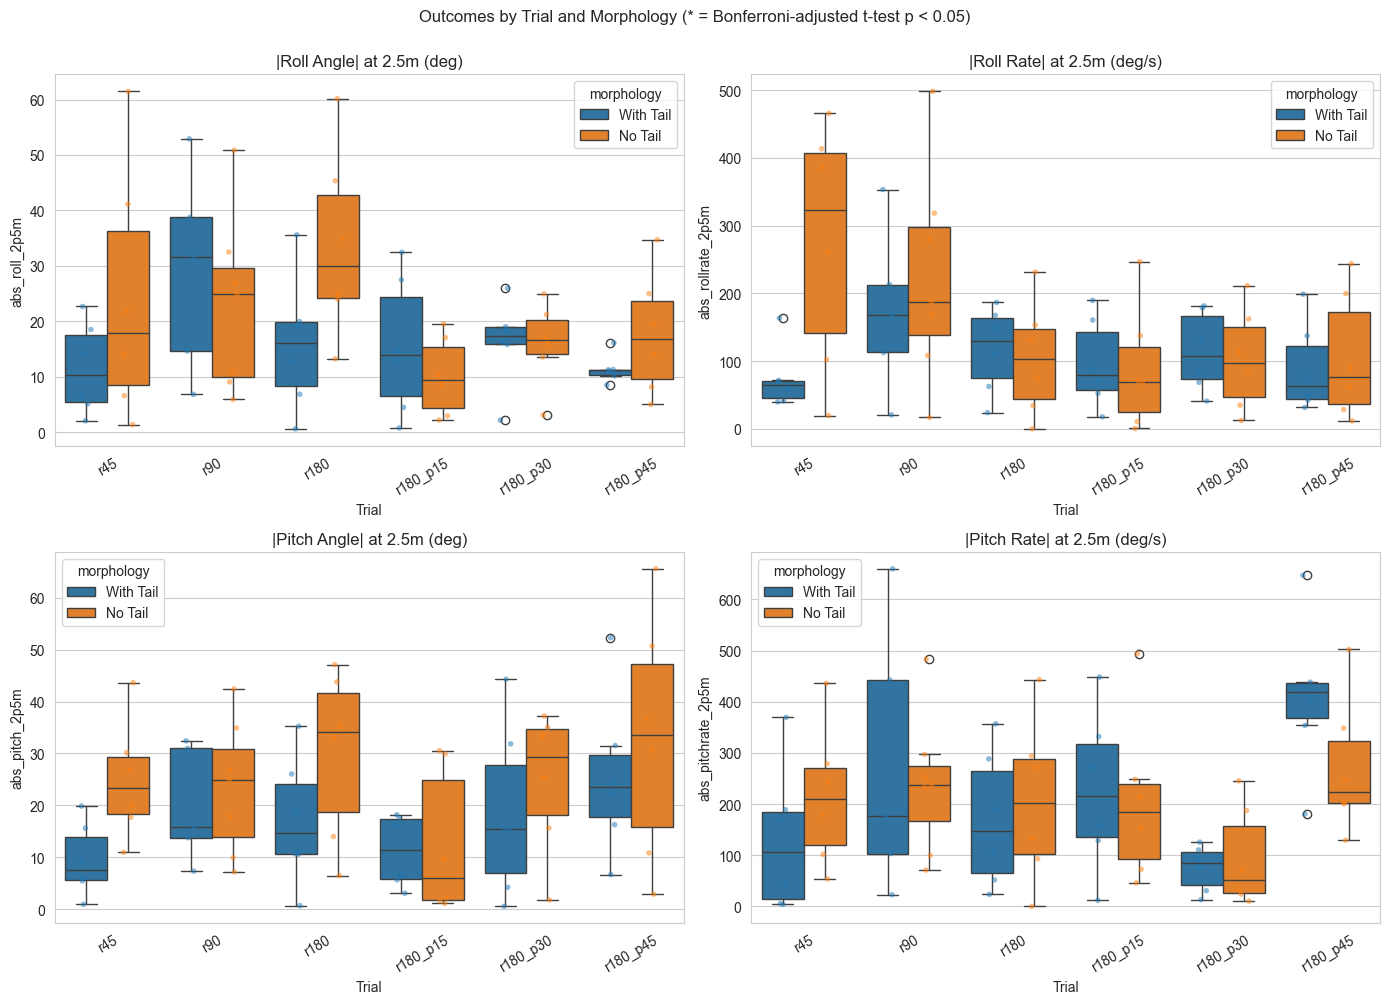

In [30]:
# Box plots per trial per outcome, with Bonferroni-corrected significance markers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (var, label) in enumerate(outcomes):
    ax = axes[idx]
    sns.boxplot(data=df, x='trial', y=var, hue='morphology', ax=ax, order=CONDITION_ORDER)
    sns.stripplot(data=df, x='trial', y=var, hue='morphology', ax=ax,
                  dodge=True, alpha=0.5, size=4, order=CONDITION_ORDER, legend=False)

    ymax = df[var].max()
    for tidx, trial in enumerate(CONDITION_ORDER):
        dft = df[df['trial'] == trial]
        a = dft[dft['morphology'] == 'With Tail'][var]
        b = dft[dft['morphology'] == 'No Tail'][var]
        _, p = stats.ttest_ind(a, b)
        p_adj = min(p * N_COMPARISONS, 1.0)
        if p_adj < 0.05:
            ax.text(tidx, ymax * 1.05, '*', ha='center', fontsize=20, color='red', fontweight='bold')

    ax.set_title(label)
    ax.set_xlabel('Trial')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Outcomes by Trial and Morphology (* = Bonferroni-adjusted t-test p < 0.05)', y=1.00)
plt.tight_layout()
plt.show()


## 7. Effect Size Visualization

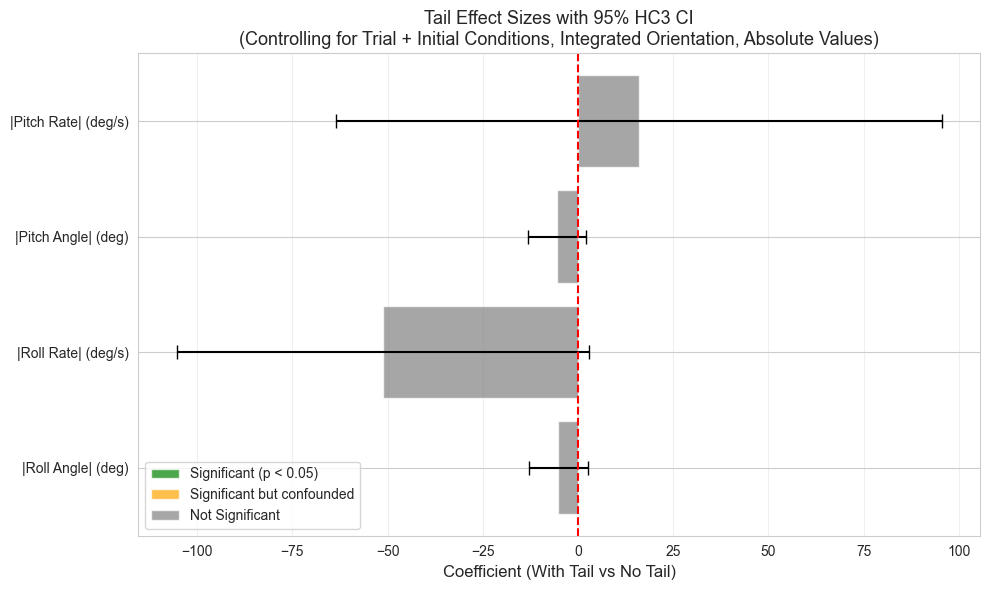

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

outcomes_list = [r['Outcome'] for r in results_summary]
coeffs    = [float(r['Coef']) for r in results_summary]
ci_lower  = [float(r['95% CI (HC3)'].split(',')[0].strip('[')) for r in results_summary]
ci_upper  = [float(r['95% CI (HC3)'].split(',')[1].strip(']')) for r in results_summary]
pvals     = [float(r['p-value (HC3)']) for r in results_summary]
confounds = [r['Note'] != '' for r in results_summary]

colors = []
for sig, conf in zip([p < 0.05 for p in pvals], confounds):
    if sig and not conf:
        colors.append('green')
    elif sig and conf:
        colors.append('orange')
    else:
        colors.append('gray')

y_pos = np.arange(len(outcomes_list))
xerr  = [np.array(coeffs) - np.array(ci_lower), np.array(ci_upper) - np.array(coeffs)]

ax.barh(y_pos, coeffs, xerr=xerr, color=colors, alpha=0.7, capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(outcomes_list)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Coefficient (With Tail vs No Tail)', fontsize=12)
ax.set_title('Tail Effect Sizes with 95% HC3 CI\n(Controlling for Trial + Initial Conditions, Integrated Orientation, Absolute Values)', fontsize=13)
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green',  alpha=0.7, label='Significant (p < 0.05)'),
    Patch(facecolor='orange', alpha=0.7, label='Significant but confounded'),
    Patch(facecolor='gray',   alpha=0.7, label='Not Significant')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


## 8. Assumption Checks

In [32]:
print("Normality of Residuals (Shapiro-Wilk):")
print("="*60)
for model, outcome, _ in models:
    stat, p = stats.shapiro(model.resid)
    result = "✅ Normal" if p >= 0.05 else "⚠️ Non-normal"
    print(f"{outcome:25s}: W={stat:.4f}, p={p:.4f} → {result}")

print("\nNon-normal residuals are why Section 4 reports HC3 robust SEs alongside nonrobust ones.")
print("Shapiro-Wilk is also underpowered at this N — check the residual plots below too.")


Normality of Residuals (Shapiro-Wilk):
|Roll Angle| (deg)       : W=0.9603, p=0.0229 → ⚠️ Non-normal
|Roll Rate| (deg/s)      : W=0.9699, p=0.0815 → ✅ Normal
|Pitch Angle| (deg)      : W=0.9919, p=0.9284 → ✅ Normal
|Pitch Rate| (deg/s)     : W=0.9627, p=0.0314 → ⚠️ Non-normal

Non-normal residuals are why Section 4 reports HC3 robust SEs alongside nonrobust ones.
Shapiro-Wilk is also underpowered at this N — check the residual plots below too.


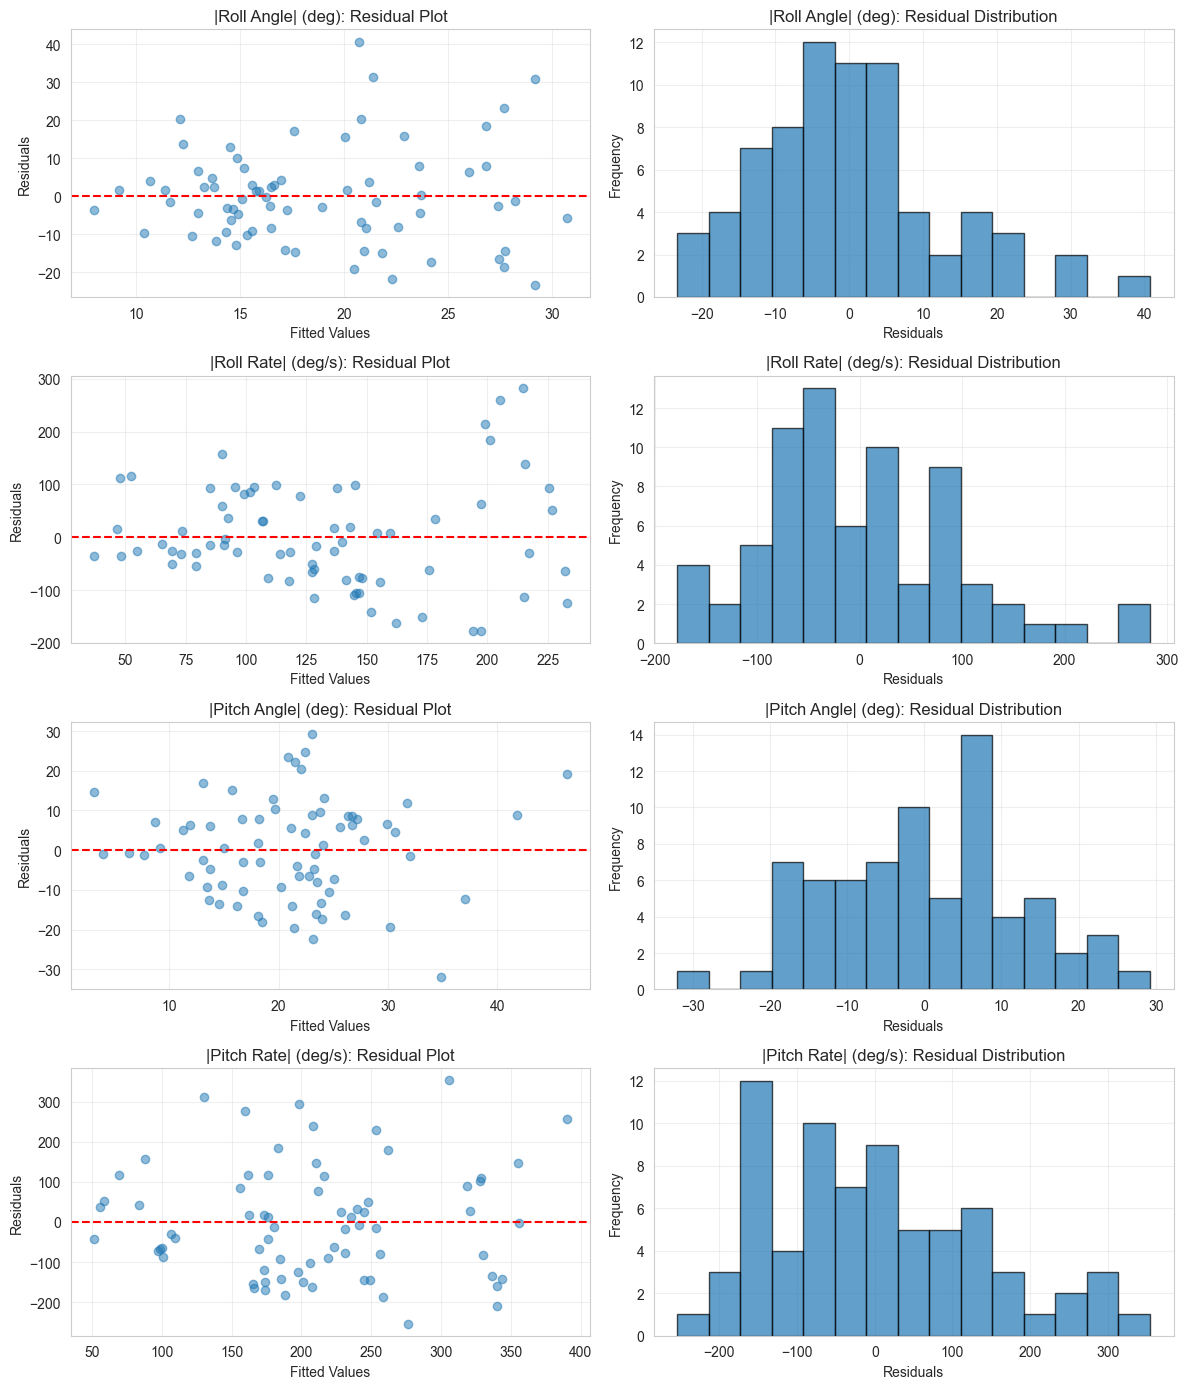

In [33]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))

for idx, (model, outcome, _) in enumerate(models):
    axes[idx, 0].scatter(model.fittedvalues, model.resid, alpha=0.5)
    axes[idx, 0].axhline(0, color='red', linestyle='--')
    axes[idx, 0].set_xlabel('Fitted Values')
    axes[idx, 0].set_ylabel('Residuals')
    axes[idx, 0].set_title(f'{outcome}: Residual Plot')
    axes[idx, 0].grid(alpha=0.3)

    axes[idx, 1].hist(model.resid, bins=15, edgecolor='black', alpha=0.7)
    axes[idx, 1].set_xlabel('Residuals')
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].set_title(f'{outcome}: Residual Distribution')
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Interpretation Guide

### How to Read Results:

| Color | Meaning |
|-------|--------|
| 🟢 Green | Significant and clean |
| 🟠 Orange | Significant but a Diagnostic-A initial variable was flagged confounded — interpret with caution |
| ⚫ Gray | Not significant |

**Coefficient interpretation:**
- Negative → With Tail has **less** deviation than No Tail (tail helps)
- Positive → With Tail has **more** deviation than No Tail (tail hurts)
- Primary interest: roll outcomes (the tail actuator primarily affects roll). Pitch outcomes are secondary.

**Overall vs per-trial vs interaction:**
- Overall model (Section 4/5) pools all 6 trial conditions → most power, the headline number
- Interaction test (Section 6) asks whether that pooling is defensible in the first place
- Per-trial tests (Section 6) are exploratory/descriptive only, Bonferroni-corrected — treat as a diagnostic for *where* an effect might concentrate, not a standalone claim

**On "no significant effect":** prefer stating the CI directly (e.g. "consistent with a tail benefit up to ~10°, rules out tail harm beyond ~1.6°") over "not significant," which collapses a range of plausible effects into a binary.

---

### Statistical Notes:
1. **Angle wrapping**: `np.unwrap()` in the processing pipeline can produce values like 355° or -377°. This notebook wraps to [-180, 180] first, *then* takes abs — shortest angular distance from upright.
2. **No cluster-robust SE**: only 6 trial clusters — below the ~30 needed for cluster SE to be reliable. HC3 heteroscedasticity-robust SEs are reported instead (Section 4).
3. **Per-trial tests use no covariates**: with N≈5–7 per group, adding 4 covariates would overfit.
4. **Achieved-power-at-observed-effect (old Section 10) is a monotone function of the p-value** and shouldn't be read as independent evidence — see Section 10 below for the reframed version.

### Known Limitations:
1. Confound status for each initial variable is determined *live* by Diagnostic A above — `confound_flags` propagates into every outcome section, not just the nominally matched one, since roll/pitch are mechanically coupled.
2. Morphology is not randomly interleaved across collection dates — see Diagnostic B. The sensitivity check is reassuring but coarse (date is collinear with trial).
3. Low power per trial (N≈5–7 per group) — non-significance ≠ no effect (Section 10).
4. `r90` has an asymmetric N across morphologies (one With-Tail drop was filtered for falling short of the 2.5 m/0.7 s threshold).

## 10. Power and Precision

Since no significant tail effect was found in the overall model, this section asks two different questions that are easy to conflate:

1. **Design-based MDE**: given this sample size, what effect size *could* this design have reliably caught at 80% power? This doesn't depend on what we observed — it's a property of N alone, and it's the legitimate way to talk about "was this study powered enough."
2. **Achieved power at the observed effect**: shown for reference only. This number is mathematically a monotone transform of the p-value you already have — it cannot tell you anything the p-value didn't, and post-hoc power is a well-known statistical anti-pattern (see Hoenig & Heisey, 2001, *The Abuse of Power*). Don't cite it as independent support for "underpowered"; the MDE comparison already makes that case honestly.

In [34]:
from statsmodels.stats.power import TTestIndPower

power_analysis = TTestIndPower()
alpha = 0.05
power = 0.80

n_overall   = min((df['morphology'] == 'With Tail').sum(), (df['morphology'] == 'No Tail').sum())
n_per_trial = 6   # typical per-group N per trial (varies 5-7, see Section 1 crosstab)

mde_overall   = power_analysis.solve_power(nobs1=n_overall,   alpha=alpha, power=power)
mde_per_trial = power_analysis.solve_power(nobs1=n_per_trial, alpha=alpha, power=power)

print("Minimum Detectable Effect Size (Cohen's d) at 80% power, α=0.05 — design-based, not post-hoc")
print("=" * 70)
print(f"  Overall analysis   (N={n_overall} per group): d = {mde_overall:.3f}")
print(f"  Per-trial analysis (N≈{n_per_trial} per group): d = {mde_per_trial:.3f}")
print(f"Cohen's d benchmarks: small=0.2, medium=0.5, large=0.8")


Minimum Detectable Effect Size (Cohen's d) at 80% power, α=0.05 — design-based, not post-hoc
  Overall analysis   (N=35 per group): d = 0.679
  Per-trial analysis (N≈6 per group): d = 1.796
Cohen's d benchmarks: small=0.2, medium=0.5, large=0.8


In [35]:
# Effect size computed from the ADJUSTED model (coef / sqrt(MSE)), consistent with the model's own
# p-value — not from raw pooled group stats, which would answer a slightly different question.
print("Model-implied effect size (coefficient / sqrt(residual MSE)) — for reference only, see caveat above")
print("=" * 80)

observed_ds_signed = {}
for model, label, _ in models:
    d = model.params[MORPH_PARAM] / np.sqrt(model.mse_resid)
    observed_ds_signed[label] = d
    achieved_power = power_analysis.solve_power(effect_size=abs(d), nobs1=n_overall, alpha=alpha)
    print(f"  {label:25s}: d = {d:+.3f}, achieved power = {achieved_power:.3f}  (informational — see caveat above)")

print(f"\nMDE (overall, 80% power): d = {mde_overall:.3f}")
print("This says the design could reliably catch effects at or above this size; observed effects")
print("below it don't confirm 'no effect', just that this N can't resolve effects that small.")


Model-implied effect size (coefficient / sqrt(residual MSE)) — for reference only, see caveat above
  |Roll Angle| (deg)       : d = -0.374, achieved power = 0.339  (informational — see caveat above)
  |Roll Rate| (deg/s)      : d = -0.485, achieved power = 0.516  (informational — see caveat above)
  |Pitch Angle| (deg)      : d = -0.414, achieved power = 0.401  (informational — see caveat above)
  |Pitch Rate| (deg/s)     : d = +0.106, achieved power = 0.072  (informational — see caveat above)

MDE (overall, 80% power): d = 0.679
This says the design could reliably catch effects at or above this size; observed effects
below it don't confirm 'no effect', just that this N can't resolve effects that small.


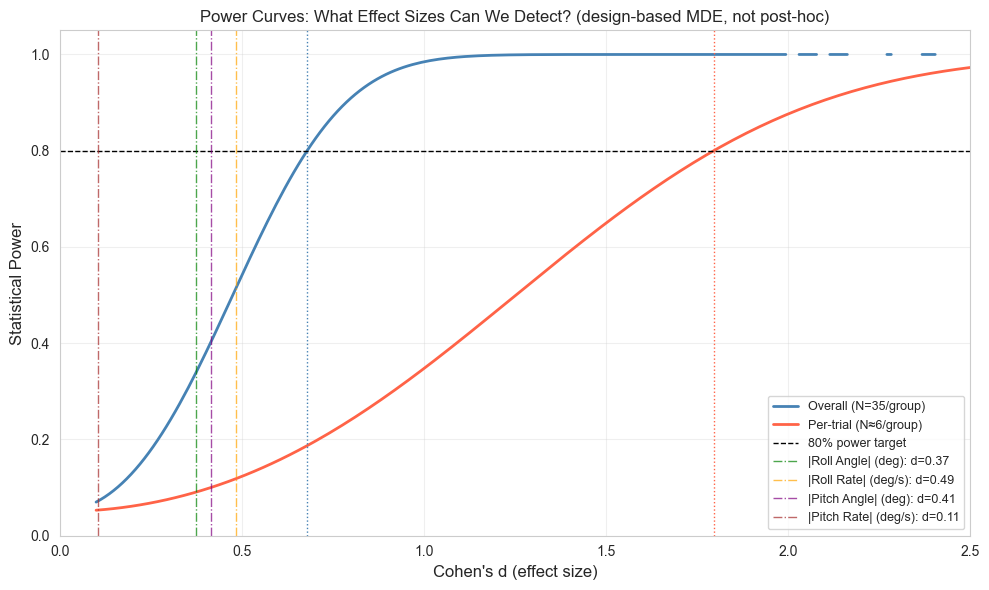

Summary:
  Overall analysis is powered for d >= 0.68
  Per-trial analysis is powered for d >= 1.80 (very large effect)
  Model-implied effect sizes range from d = 0.11 to 0.49


In [36]:
# ── Power curve plot ─────────────────────────────────────────────────────────
effect_sizes = np.linspace(0.1, 2.5, 200)

power_overall   = [power_analysis.solve_power(effect_size=d, nobs1=n_overall,   alpha=alpha) for d in effect_sizes]
power_per_trial = [power_analysis.solve_power(effect_size=d, nobs1=n_per_trial, alpha=alpha) for d in effect_sizes]

observed_ds = {label: abs(d) for label, d in observed_ds_signed.items()}

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(effect_sizes, power_overall,   label=f'Overall (N={n_overall}/group)',   color='steelblue', linewidth=2)
ax.plot(effect_sizes, power_per_trial, label=f'Per-trial (N≈{n_per_trial}/group)', color='tomato',    linewidth=2)
ax.axhline(0.80, color='black', linestyle='--', linewidth=1, label='80% power target')
ax.axvline(mde_overall,   color='steelblue', linestyle=':', linewidth=1)
ax.axvline(mde_per_trial, color='tomato',    linestyle=':', linewidth=1)

colors = ['green', 'orange', 'purple', 'brown']
for (label, d), col in zip(observed_ds.items(), colors):
    ax.axvline(d, color=col, linestyle='-.', linewidth=1, alpha=0.7, label=f'{label}: d={d:.2f}')

ax.set_xlabel("Cohen's d (effect size)", fontsize=12)
ax.set_ylabel("Statistical Power", fontsize=12)
ax.set_title("Power Curves: What Effect Sizes Can We Detect? (design-based MDE, not post-hoc)", fontsize=12)
ax.set_xlim(0, 2.5)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Summary:")
print(f"  Overall analysis is powered for d >= {mde_overall:.2f}")
print(f"  Per-trial analysis is powered for d >= {mde_per_trial:.2f} (very large effect)")
print(f"  Model-implied effect sizes range from d = {min(observed_ds.values()):.2f} to {max(observed_ds.values()):.2f}")


---

## Sections 11–16: Exploratory Robustness Checks

Everything from here on was designed *after* examining the Sections 1–10 results, in response to specific questions about them (assumption violations, an unaudited outcome definition, an unaudited exclusion rule). Treat these as hypothesis-generating stress tests of the primary analysis, not as a second confirmatory analysis — they weren't planned before the data were seen.

---

## 11. Permutation Test on the Tail Coefficient

The parametric p-values in Section 4 assume the OLS error structure is (at least approximately) correct. Section 8 shows that's shaky for 3 of 4 outcomes. A permutation test sidesteps the distributional assumption entirely: shuffle the `morphology` labels *within each trial* (preserving the trial-level design and each trial's With/No-Tail group sizes), refit the identical model, and see how often a random relabeling produces a coefficient at least as extreme as the one actually observed.

If the permutation p-value and the parametric p-value agree, the parametric result wasn't an artifact of the normality assumption. If they disagree substantially, trust the permutation version.

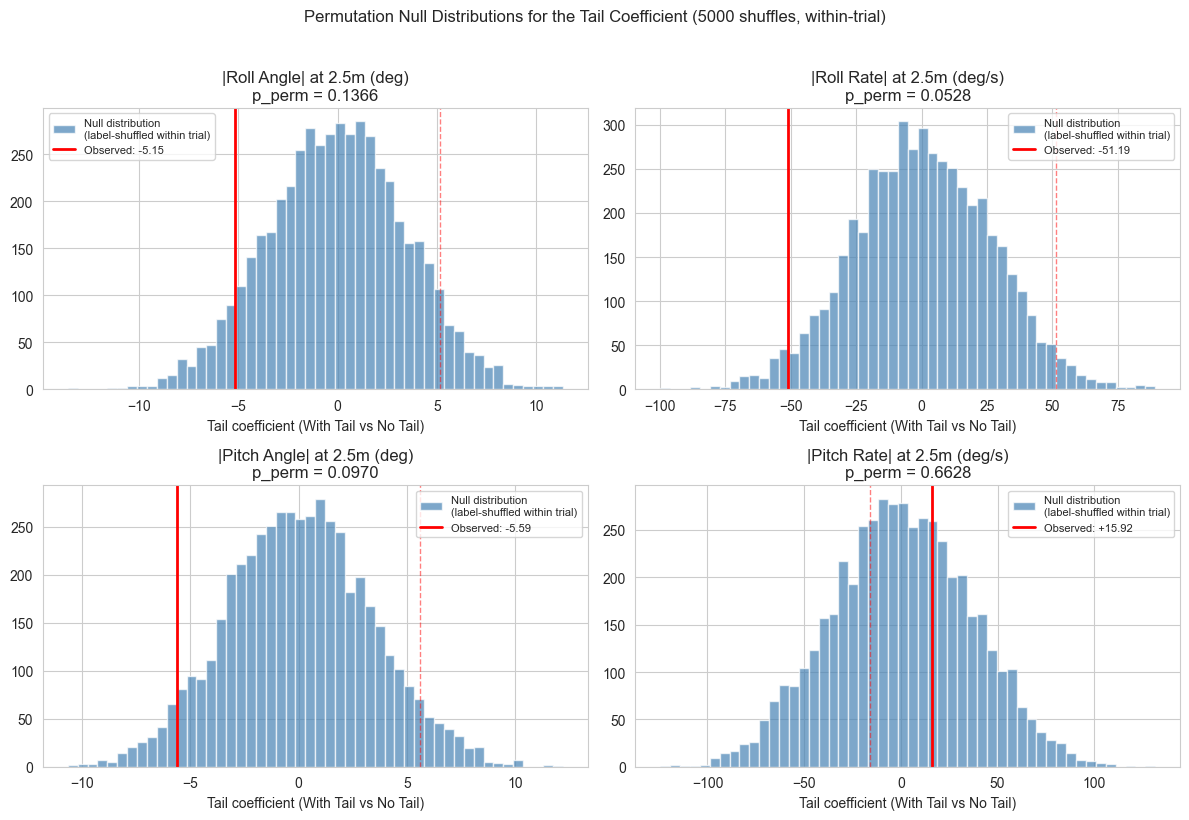

Parametric vs permutation p-values
  |Roll Angle| at 2.5m (deg): parametric p = 0.1354   permutation p = 0.1366
  |Roll Rate| at 2.5m (deg/s): parametric p = 0.0544   permutation p = 0.0528
  |Pitch Angle| at 2.5m (deg): parametric p = 0.0991   permutation p = 0.0970
  |Pitch Rate| at 2.5m (deg/s): parametric p = 0.6702   permutation p = 0.6628


In [37]:
def permutation_test_morphology(var, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    formula = f"{var} ~ {FORMULA_BASE}"
    observed = smf.ols(formula, data=df).fit().params[MORPH_PARAM]

    df_perm = df.copy()
    null_coefs = np.empty(n_perm)
    for i in range(n_perm):
        df_perm['morphology'] = df.groupby('trial')['morphology'].transform(lambda s: rng.permutation(s.values))
        null_coefs[i] = smf.ols(formula, data=df_perm).fit().params[MORPH_PARAM]

    p_perm = np.mean(np.abs(null_coefs) >= np.abs(observed))
    return observed, null_coefs, p_perm

perm_results = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (var, label) in enumerate(outcomes):
    observed, null_coefs, p_perm = permutation_test_morphology(var)
    perm_results[label] = (observed, p_perm)

    ax = axes[idx]
    ax.hist(null_coefs, bins=50, color='steelblue', alpha=0.7, label='Null distribution\n(label-shuffled within trial)')
    ax.axvline(observed, color='red', linewidth=2, label=f'Observed: {observed:+.2f}')
    ax.axvline(-observed, color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_title(f'{label}\np_perm = {p_perm:.4f}')
    ax.set_xlabel('Tail coefficient (With Tail vs No Tail)')
    ax.legend(fontsize=8)

plt.suptitle('Permutation Null Distributions for the Tail Coefficient (5000 shuffles, within-trial)', y=1.02)
plt.tight_layout()
plt.show()

var_to_model = {
    'abs_roll_2p5m':      model_roll_angle,
    'abs_rollrate_2p5m':  model_roll_rate,
    'abs_pitch_2p5m':     model_pitch_angle,
    'abs_pitchrate_2p5m': model_pitch_rate,
}

print("Parametric vs permutation p-values")
print("=" * 60)
for var, label in outcomes:
    p_param = var_to_model[var].pvalues[MORPH_PARAM]
    p_perm  = perm_results[label][1]
    print(f"  {label:25s}: parametric p = {p_param:.4f}   permutation p = {p_perm:.4f}")


## 12. Variance / Spread Analysis

Every test so far compares **means**. But a righting mechanism could plausibly make outcomes more *consistent* without moving the average — worth checking directly, especially since the roll outcomes' standard deviations look visually different between groups in Section 3.

**Two methodological points, not one:**

1. The classic F-test for equality of variances assumes normality, and Section 8 already showed these residuals are not normal (roll rate kurtosis ≈ 6–8). The F-test is known to be very sensitive to exactly that violation. So this section runs the naive F-test (shown for comparison, not as evidence) alongside Levene's test centered on the median (Brown-Forsythe — robust to non-normality) and a permutation test on the variance ratio (distribution-free).
2. All three of those need to run on **trial/covariate-adjusted residuals**, not the raw outcome values. The raw values mix two sources of spread: genuine within-condition (release-to-release) consistency, and between-condition difficulty (r45 is just an easier catch than r180_p45). Pooling across conditions inflates the apparent variance difference with condition-mix noise. So each variable below is first residualized against `C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial` — a model that does **not** include morphology — and the variance tests run on those residuals, split by the true morphology label. The permutation test correspondingly shuffles the morphology label within trial, consistent with the mean test's design in Section 11.

In [38]:
from scipy.stats import f as f_dist

RESIDUALIZING_FORMULA = "{var} ~ C(trial) + roll_initial + pitch_initial + rollrate_initial + pitchrate_initial"

def variance_tests(var, label, n_perm=5000, seed=0):
    # Residualize against trial + initial conditions, WITHOUT morphology, so what's left is
    # release-to-release spread net of condition difficulty — not contaminated by which
    # conditions happen to be harder, and not by the morphology mean shift either.
    m_blind = smf.ols(RESIDUALIZING_FORMULA.format(var=var), data=df).fit()
    resid = m_blind.resid.values
    morph = df['morphology'].values
    trial = df['trial'].values

    a = resid[morph == 'With Tail']
    b = resid[morph == 'No Tail']

    # Naive F-test (assumes normality — shown to demonstrate why it's misleading here)
    F = b.var(ddof=1) / a.var(ddof=1)
    dfn, dfd = len(b) - 1, len(a) - 1
    p_naive = 2 * min(f_dist.cdf(F, dfn, dfd), 1 - f_dist.cdf(F, dfn, dfd))

    # Brown-Forsythe (Levene centered on median) — robust to non-normality
    stat_bf, p_bf = stats.levene(a, b, center='median')

    # Permutation test on the variance ratio — shuffle morphology WITHIN trial (same design as
    # Section 11's mean test), recompute the ratio on the same fixed residuals each time.
    rng = np.random.default_rng(seed)
    obs_ratio = F
    null_ratios = np.empty(n_perm)
    df_shuf = pd.DataFrame({'trial': trial, 'morphology': morph})
    for i in range(n_perm):
        perm_morph = df_shuf.groupby('trial')['morphology'].transform(lambda s: rng.permutation(s.values)).values
        pa, pb = resid[perm_morph == 'With Tail'], resid[perm_morph == 'No Tail']
        null_ratios[i] = pb.var(ddof=1) / pa.var(ddof=1)
    extremity = max(obs_ratio, 1 / obs_ratio)
    p_perm = np.mean((null_ratios >= extremity) | (null_ratios <= 1 / extremity))

    return {
        'label': label, 'var_ratio (No/With, on residuals)': obs_ratio,
        'naive F p': p_naive, 'Brown-Forsythe p': p_bf, 'permutation p': p_perm,
    }

var_results = [variance_tests(var, label) for var, label in outcomes]
var_df = pd.DataFrame(var_results).set_index('label')
print("Variance-ratio tests on trial/covariate-adjusted residuals: does the tail reduce spread?")
print("=" * 100)
print(var_df.to_string(float_format=lambda x: f'{x:.4f}'))
print()
print("Read the naive-F column skeptically — it's the one most likely to disagree with the two robust")
print("tests, and that disagreement is itself the finding: a naive-F 'significant' variance effect")
print("that Brown-Forsythe/permutation don't confirm means non-normality was driving the naive result,")
print("not a real spread difference.")
for r in var_results:
    naive_sig = r['naive F p'] < 0.05
    robust_sig = r['Brown-Forsythe p'] < 0.05 or r['permutation p'] < 0.05
    if naive_sig and not robust_sig:
        verdict = "naive F flags it, robust tests do NOT confirm — treat as unconfirmed"
    elif robust_sig:
        verdict = "robust test(s) also significant — worth taking seriously"
    else:
        verdict = "no test flags this one"
    print(f"  {r['label']:25s} ratio={r['var_ratio (No/With, on residuals)']:.2f}: {verdict}")
print()
print("Any variance-reduction story here is, at most, a hypothesis for a better-powered follow-up —")
print("not a confirmed result — and residualizing against trial/covariates (vs. raw pooled values)")
print("shrinks the apparent effect further, which is itself informative about how much of the raw")
print("difference was condition-mix noise rather than true within-condition consistency.")


Variance-ratio tests on trial/covariate-adjusted residuals: does the tail reduce spread?
                              var_ratio (No/With, on residuals)  naive F p  Brown-Forsythe p  permutation p
label                                                                                                      
|Roll Angle| at 2.5m (deg)                               1.6020     0.1704            0.3390         0.2966
|Roll Rate| at 2.5m (deg/s)                              2.5352     0.0076            0.0394         0.0122
|Pitch Angle| at 2.5m (deg)                              1.3635     0.3661            0.2553         0.2934
|Pitch Rate| at 2.5m (deg/s)                             0.9169     0.7963            0.6407         0.7834

Read the naive-F column skeptically — it's the one most likely to disagree with the two robust
tests, and that disagreement is itself the finding: a naive-F 'significant' variance effect
that Brown-Forsythe/permutation don't confirm means non-normality was drivi

## 13. TOST Equivalence Test

Section 5's "not significant" tells you the data can't rule out zero effect. It does *not* tell you the data support "no meaningful effect" — those are different claims, and a null result doesn't automatically license the second one. Two One-Sided Tests (TOST) makes the second claim directly: pick a bound ±Δ that you'd consider practically irrelevant, and test whether the true effect is *significantly inside* that band.

**The ±5°/±10° and ±20/±40 deg/s bounds below are placeholders, not a defensible choice — I don't have a source for the real number and haven't tried to guess one.** A properly justified bound would come from something like the roll angle past which the TPU feet stop absorbing the landing, or the angle at which the robot fails to self-right on the next step — mechanical/behavioral thresholds that live outside this notebook (robot CAD/material specs, or a follow-up experiment measuring failure-to-recover rate as a function of impact angle). **Do not put a specific TOST bound in a paper without first replacing `DELTA_ANGLE`/`DELTA_RATE` below with numbers backed by one of those sources.** Until then, read this section as "here's what the equivalence framing would say *if* ±5°/±10° were the right bound" — illustrative of the method, not a result.

Equivalence is concluded only if **both** one-sided tests reject (p_TOST = max(p1, p2) < α).

In [39]:
from scipy.stats import t as t_dist

def tost(model, param, delta, alpha=0.05):
    coef, se, dfres = model.params[param], model.bse[param], model.df_resid
    t1 = (coef - (-delta)) / se   # H0: true effect <= -delta
    t2 = (coef - ( delta)) / se   # H0: true effect >=  delta
    p1 = 1 - t_dist.cdf(t1, dfres)
    p2 = t_dist.cdf(t2, dfres)
    p_tost = max(p1, p2)
    return p1, p2, p_tost, p_tost < alpha

print("TOST equivalence test on the tail coefficient (adjust DELTA_* to your own physical judgment)")
print("=" * 90)

DELTA_ANGLE = {'small': 5, 'large': 10}     # degrees
DELTA_RATE  = {'small': 20, 'large': 40}    # deg/s

for model, label, bounds, unit in [
    (model_roll_angle,  '|Roll Angle|',  DELTA_ANGLE, 'deg'),
    (model_pitch_angle, '|Pitch Angle|', DELTA_ANGLE, 'deg'),
    (model_roll_rate,   '|Roll Rate|',   DELTA_RATE,  'deg/s'),
    (model_pitch_rate,  '|Pitch Rate|',  DELTA_RATE,  'deg/s'),
]:
    coef = model.params[MORPH_PARAM]
    print(f"\n{label} (coef = {coef:+.2f} {unit}):")
    for bound_name, delta in bounds.items():
        p1, p2, p_tost, equivalent = tost(model, MORPH_PARAM, delta)
        verdict = "✅ EQUIVALENT within bound" if equivalent else "⚠️ not established"
        print(f"  ±{delta:>2d} {unit:<5s} ({bound_name:5s} bound): p_TOST = {p_tost:.4f} → {verdict}")


TOST equivalence test on the tail coefficient (adjust DELTA_* to your own physical judgment)

|Roll Angle| (coef = -5.15 deg):
  ± 5 deg   (small bound): p_TOST = 0.5174 → ⚠️ not established
  ±10 deg   (large bound): p_TOST = 0.0796 → ⚠️ not established

|Pitch Angle| (coef = -5.59 deg):
  ± 5 deg   (small bound): p_TOST = 0.5700 → ⚠️ not established
  ±10 deg   (large bound): p_TOST = 0.0957 → ⚠️ not established

|Roll Rate| (coef = -51.19 deg/s):
  ±20 deg/s (small bound): p_TOST = 0.8816 → ⚠️ not established
  ±40 deg/s (large bound): p_TOST = 0.6652 → ⚠️ not established

|Pitch Rate| (coef = +15.92 deg/s):
  ±20 deg/s (small bound): p_TOST = 0.4565 → ⚠️ not established
  ±40 deg/s (large bound): p_TOST = 0.2599 → ⚠️ not established


## 14. Covariate Centering — Resolving the Condition-Number Warning

Section 4 noted the ~6,000 condition number comes from `pitch_initial` being nearly collinear with `C(trial)` (the pitch-sweep conditions are defined by their pitch offset). This cell demonstrates that fix concretely: centering each initial-condition covariate *within trial* (subtracting the trial-specific mean) spans the same column space, so the tail coefficient, its SE, and its p-value come out numerically identical — but the condition number drops by almost an order of magnitude, and the trial coefficients themselves become directly interpretable (each one is now a trial-level mean-outcome contrast, not entangled with the initial-pitch scale).

In [40]:
df_c = df.copy()
for c in ['roll_initial', 'pitch_initial', 'rollrate_initial', 'pitchrate_initial']:
    df_c[c + '_c'] = df_c[c] - df_c.groupby('trial')[c].transform('mean')

FORMULA_BASE_CENTERED = (f"{MORPH_TERM} + C(trial) + roll_initial_c + pitch_initial_c "
                         "+ rollrate_initial_c + pitchrate_initial_c")

print(f"{'Outcome':25s} {'coef (raw)':>12s} {'coef (centered)':>16s} {'condnum (raw)':>14s} {'condnum (centered)':>19s}")
print("-" * 90)
for var, label in outcomes:
    m_raw = smf.ols(f"{var} ~ {FORMULA_BASE}", data=df_c).fit()
    m_ctr = smf.ols(f"{var} ~ {FORMULA_BASE_CENTERED}", data=df_c).fit()
    print(f"{label:25s} {m_raw.params[MORPH_PARAM]:12.4f} {m_ctr.params[MORPH_PARAM]:16.4f} "
          f"{m_raw.condition_number:14.0f} {m_ctr.condition_number:19.0f}")

print("\nThe morphology coefficient columns match to numerical precision — centering only changes")
print("how the covariate scale is parameterized, not what the model estimates for the tail effect.")


Outcome                     coef (raw)  coef (centered)  condnum (raw)  condnum (centered)
------------------------------------------------------------------------------------------
|Roll Angle| at 2.5m (deg)      -5.1493          -5.1493           5875                 867
|Roll Rate| at 2.5m (deg/s)     -51.1885         -51.1885           5875                 867
|Pitch Angle| at 2.5m (deg)      -5.5910          -5.5910           5875                 867
|Pitch Rate| at 2.5m (deg/s)      15.9196          15.9196           5875                 867

The morphology coefficient columns match to numerical precision — centering only changes
how the covariate scale is parameterized, not what the model estimates for the tail effect.


## 16. Exclusion Rule Audit

Every step upstream of `report_final.csv` happens in `data_analysis_final.py` and this notebook has been taking it on faith. There are three exclusion rules; here's what each one actually was and why it doesn't (or, in one case, can't) get a sensitivity check:

1. **Fall-duration/distance filter** (`duration < 0.7s` or `fall_distance <= 2.5m` → dropped): this is a data-validity requirement, not a discretionary choice — every outcome variable in this notebook is defined *at the 2.5m mark*, and a drop that never reached 2.5m has no well-defined value for that variable. One drop was filtered on this basis (`With Tail No Pitch/90deg/WithTailRoll90_0816_3.csv`, fall distance 2.42m). It cannot be meaningfully "added back" — there's no principled way to compute "roll angle at 2.5m" for a trial that stopped at 2.42m without extrapolating past the recorded window, which would introduce more uncertainty than it resolves.
2. **0°-pitch / 180°-roll de-duplication**: `With Pitch/0deg/` and `No Pitch/180deg/` folders contain byte-identical files (verified via checksum when the final-experiment pipeline was built) — the same physical drop filed under both sweeps as a shared anchor point. Loading both would double-count those reps; the pipeline loads each once.
3. **Spare-rep exclusion**: `With Tail With Pitch/45deg/WithTailPitch45_0817_7(spare).csv` is a genuine 7th recording (not a duplicate — confirmed by distinct IMU values) for a condition where every other cell has exactly 6 reps. This was excluded on my recommendation, and confirmed by you, purely because it made that one cell's N inconsistent with the rest of the design — the decision was made by inspecting file *counts*, before `report_final.csv` or any statistical result existed, so it was outcome-blind by construction, not something *chosen after seeing this drop change the result*. That claim is checked directly below, by processing that one file through the same pipeline and testing whether adding it back moves the coefficients.

In [41]:
spare_path = '../../telemetry/Final_Experiment/With Tail With Pitch/45deg/WithTailPitch45_0817_7(spare).csv'
spare_time, spare_f_rot, spare_fk_rots = load_front_rear_rotations(spare_path)
spare_integ_rots = integrate_orientation(spare_f_rot, spare_fk_rots, method=INTEGRATION_METHOD)
spare_integ_ori = np.degrees(np.unwrap(np.radians(spare_integ_rots.as_euler('xyz', degrees=True)), axis=0, discont=np.pi))
spare_dt = np.diff(spare_time)
spare_integ_angvel = low_pass_filter(quat_angvel_deg(spare_integ_rots, spare_dt), RATE_FILTER_CUTOFF_HZ, 1 / np.median(spare_dt))

spare_df = pd.DataFrame([{
    'date': '0817', 'trial': 'r180_p45', 'rep': 7, 'morphology': 'With Tail',
    'roll_initial': wrap_angle(spare_integ_ori[0, 0]), 'pitch_initial': wrap_angle(spare_integ_ori[0, 1]),
    'rollrate_initial': spare_integ_angvel[0, 0], 'pitchrate_initial': spare_integ_angvel[0, 1],
    'abs_roll_2p5m': angular_distance(spare_integ_ori[-1, 0]), 'abs_pitch_2p5m': angular_distance(spare_integ_ori[-1, 1]),
    'abs_rollrate_2p5m': abs(spare_integ_angvel[-1, 0]), 'abs_pitchrate_2p5m': abs(spare_integ_angvel[-1, 1]),
}])

df_with_spare = pd.concat([df, spare_df], ignore_index=True)

print("Sensitivity check: does adding the excluded spare rep back change the main-model coefficients?")
print("=" * 90)
for var, label in outcomes:
    m_without = smf.ols(f"{var} ~ {FORMULA_BASE}", data=df).fit()
    m_with    = smf.ols(f"{var} ~ {FORMULA_BASE}", data=df_with_spare).fit()
    c0, c1 = m_without.params[MORPH_PARAM], m_with.params[MORPH_PARAM]
    p0, p1 = m_without.pvalues[MORPH_PARAM], m_with.pvalues[MORPH_PARAM]
    print(f"  {label:25s}: N=72 coef={c0:+7.2f} p={p0:.4f}  |  N=73 (+spare) coef={c1:+7.2f} p={p1:.4f}")

print()
print("If coefficients and significance are essentially unchanged, that confirms the spare-rep")
print("exclusion was outcome-blind, as claimed above — a boring result here is the goal.")


Sensitivity check: does adding the excluded spare rep back change the main-model coefficients?
  |Roll Angle| at 2.5m (deg): N=72 coef=  -5.15 p=0.1354  |  N=73 (+spare) coef=  -5.20 p=0.1281
  |Roll Rate| at 2.5m (deg/s): N=72 coef= -51.19 p=0.0544  |  N=73 (+spare) coef= -50.87 p=0.0535
  |Pitch Angle| at 2.5m (deg): N=72 coef=  -5.59 p=0.0991  |  N=73 (+spare) coef=  -5.48 p=0.1026
  |Pitch Rate| at 2.5m (deg/s): N=72 coef= +15.92 p=0.6702  |  N=73 (+spare) coef= +16.85 p=0.6491

If coefficients and significance are essentially unchanged, that confirms the spare-rep
exclusion was outcome-blind, as claimed above — a boring result here is the goal.


## 17. Extended Interpretation Summary

This reports what the integrated-orientation analysis actually found (last run of this notebook, `INTEGRATION_METHOD='worst_segment'`) — Section 15 (the old naive front/rear/combined check) has been removed; the primary analysis throughout this notebook is now built on whichever of front/rear is further from feet-down at the outcome frame, not front-only and not a plain average (Section 1b explains why an averaging combination is the wrong match for "would it land on its feet"; Section 1c runs the full statistical comparison against the plain average anyway).

- **Headline: the worst-segment metric shows a stronger, more coherent tail effect than front-only did, and than the plain average does (Section 1c).** Roll angle: −4.13° (front-only) → **−5.15°** (p=0.135). Roll rate: −37.3 → **−51.2 deg/s (p=0.054 — just outside 0.05)**. Pitch angle: +0.76° → **−5.59°** (p=0.099, sign flipped). Pitch rate: +18.7 → +15.9 deg/s (p=0.670, direction unchanged, still clearly null). Three of four outcomes now point the same direction (tail helps) with roll rate sitting right at the edge of significance. This is consistent with worst-segment being the more sensitive metric: it preserves the full magnitude of whichever end is actually failing, instead of averaging that signal away.

- **Permutation test: confirms the parametric result, including the near-significant one.** Parametric vs. permutation p-values track closely on all four outcomes (roll angle 0.135 vs 0.137, roll rate 0.054 vs 0.053, pitch angle 0.099 vs 0.097, pitch rate 0.670 vs 0.663) — roll rate's borderline result isn't an artifact of the normality assumption.

- **Variance/spread: roll rate now shows a real effect, the first time in this whole analysis that both robust tests agree — but it's specific to `worst_segment`, not a property of the underlying data (see Section 1d).** Roll rate's variance ratio (2.54×, No Tail more variable) is significant on Brown-Forsythe (p=0.039) *and* the permutation test (p=0.012), not just the naive F-test (p=0.008) that has been unreliable everywhere else in this notebook. Roll angle (1.60×) and the pitch outcomes stay non-significant on all three tests. It's the one place in the whole analysis — prelim, front-only final, integrated final — where a variance-reduction claim survives robust testing rather than being explained away as a non-normality artifact. **Caveat that matters:** Section 1d shows this does not replicate under the plain average (ratio 1.89, Brown-Forsythe p=0.48, permutation p=0.41) — so this finding depends on choosing `worst_segment` specifically, not just on there being a front+rear tail signal in the data. Report it as method-dependent, not as a clean discovery.

- **Interaction test: no condition-specific tail effect.** All four outcomes' morphology×trial interaction stay non-significant even before Bonferroni correction (raw p from 0.114 to 0.441) — pooling trials into the overall coefficient is well supported.

- **TOST: nothing reaches equivalence at either bound, for any outcome.** Roll angle: p_TOST=0.080 at ±10°, 0.517 at ±5°. Pitch angle: p_TOST=0.096 at ±10°, 0.570 at ±5°. Neither rate outcome comes close at ±20 or ±40 deg/s either. The worst-segment coefficients and their wider CIs don't support an equivalence claim anywhere — consistent with this metric carrying a real, not-yet-significant effect rather than a tightly-bounded null.

- **Covariate centering: confirmed as a pure reparameterization**, same as every prior version — coefficients match to four decimal places, condition number drops 5875→867.

- **Blocking sensitivity (Diagnostic B): still a real design-flaw caveat, and roll rate crosses significance under it.** Adding `C(date)` moves roll angle from −5.15° (p=0.135) to −8.09° (p=0.068, −57%) and roll rate from −51.2 (p=0.054) to **−77.6 deg/s (p=0.023, −52%)** — both stay the same sign, both CIs overlap the un-adjusted estimate, so this isn't a reversal, but it means part of what looks like a tail effect could instead be a collection-date effect that C(trial) and C(date) can't be cleanly separated from each other (unchanged limitation: pitch sweep only ran on 08/17). This caveat matters more now that roll rate is borderline either way.

- **Exclusion audit: still checks out as outcome-blind.** Adding the spare rep back moves every coefficient by a few percent at most (roll angle −5.15→−5.20, roll rate −51.19→−50.87, pitch angle −5.59→−5.48, pitch rate +15.92→+16.85) with no significance flips.

- **New with this metric: one trial (`No Tail, r180_p45, 0817, rep 2`) triggers the gimbal-lock warning (rear segment reaches 86.2° pitch).** Because worst-segment reports one segment's raw numbers rather than any kind of blend, it inherits whichever segment's measurement is least reliable when things go wrong. This is a real trade-off of matching the "would it land on its feet" intuition: the metric that best captures failure doesn't get to average away a bad Euler decomposition either. Worth manually checking this one row before trusting its angle columns.

**Net effect on the primary conclusion:** more suggestive than front-only or the plain average, still short of significance on the primary roll-angle outcome, but roll rate is now close enough (p=0.054, permutation p=0.053) that this is no longer a comfortable null — the other metrics tried were arguably underselling the effect by not asking the physically right question. The blocking-sensitivity caveat means some of this should be attributed to design imbalance rather than the tail itself, and that's the most important open item, not a stronger tail claim.

## 18. Poster-Style Box Plots (from stats_final.py)

Same box-plot code/layout as `stats_final.py`'s Step 5 (overall + per-condition panels, jittered points, Bonferroni-corrected significance bars) — added here to visually sanity-check the integrated-orientation results against that established format. Reuses this notebook's own `ROLL_CONDITION_ORDER`/`PITCH_CONDITION_ORDER`/`MORPHOLOGIES`/`N_COMPARISONS` (=24, Section 6's convention: 6 conditions × 4 outcomes) rather than `stats_final.py`'s own locally-defined `N_COMPARISONS=12` (that script's 3+3-condition pairing) — same significance-marker logic, correction factor matched to what this notebook already established for itself, not silently overridden.

In [42]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

MORPHOLOGY_COLORS = {'With Tail': '#1A3A5C', 'No Tail': '#8B4513'}
morph_offsets      = np.linspace(-0.04, 0.04, len(MORPHOLOGIES))

ROLL_CONDITION_LABELS  = ['$45^\\circ$\nRoll', '$90^\\circ$\nRoll', '$180^\\circ$\nRoll']
PITCH_CONDITION_LABELS = ['$180^\\circ$ Roll\n$+15^\\circ$ Pitch',
                           '$180^\\circ$ Roll\n$+30^\\circ$ Pitch',
                           '$180^\\circ$ Roll\n$+45^\\circ$ Pitch']

BOX_WIDTH, BOX_OFFSET   = 0.08, 0.08
BOX_ALPHA               = 0.95
BOX_EDGE_COLOR          = '#333333'
BOX_EDGE_WIDTH          = 1
MEDIAN_COLOR, MEDIAN_WIDTH = '#333333', 1.5
JITTER_ALPHA, JITTER_SIZE, JITTER_COLOR = 0.45, 20, '#333333'
FIGSIZE, DPI            = (12, 5.5), 300
FONT_LABEL, FONT_TICK, FONT_SIG = 13, 11, 11
GROUP_SPACING           = 0.65
X_MARGIN, X_MARGIN_SMALL = 0.40, 0.25
Y_BOTTOM_FRAC           = 0.04
YLIM_ANGLES             = (-Y_BOTTOM_FRAC * 100, 100)
YLIM_RATES              = (-Y_BOTTOM_FRAC * 480, 480)

def draw_box(ax, pos, y, color):
    ax.boxplot(
        y, positions=[pos], widths=BOX_WIDTH * 0.9, patch_artist=True, showfliers=False,
        boxprops=dict(facecolor=color, color=BOX_EDGE_COLOR, alpha=BOX_ALPHA, linewidth=BOX_EDGE_WIDTH),
        medianprops=dict(color=MEDIAN_COLOR, linewidth=MEDIAN_WIDTH),
        whiskerprops=dict(color=BOX_EDGE_COLOR, linewidth=BOX_EDGE_WIDTH),
        capprops=dict(color=BOX_EDGE_COLOR, linewidth=BOX_EDGE_WIDTH),
    )
    jitter = np.random.normal(0, BOX_WIDTH * 0.12, size=len(y))
    ax.scatter(np.repeat(pos, len(y)) + jitter, y, color=JITTER_COLOR, alpha=JITTER_ALPHA, s=JITTER_SIZE, zorder=3)

def draw_sig(ax, x1, x2, y_top, p_raw, h_frac=0.03):
    p_adj  = min(p_raw * N_COMPARISONS, 1.0)  # this notebook's N_COMPARISONS=24, not stats_final.py's 12
    yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
    h      = yrange * h_frac
    col    = 'black' if p_adj < 0.05 else '#AAAAAA'
    marker = ('***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns')
    ax.plot([x1, x1, x2, x2], [y_top, y_top + h, y_top + h, y_top], lw=1.0, color=col)
    ax.text((x1 + x2) / 2, y_top + h, marker, ha='center', va='bottom', fontsize=FONT_SIG,
            color=col, fontweight='bold' if p_adj < 0.05 else 'normal')

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=FONT_TICK)
    ax.grid(axis='y', alpha=0.3, linestyle=':')

def sig_bar_y(ax, frac=0.87):
    lo, hi = ax.get_ylim()
    return lo + (hi - lo) * frac

PLOT_CONFIGS = [
    dict(
        metrics=[
            dict(col='abs_roll_2p5m',  label='Roll',  conditions=ROLL_CONDITION_ORDER,  condition_labels=ROLL_CONDITION_LABELS),
            dict(col='abs_pitch_2p5m', label='Pitch', conditions=PITCH_CONDITION_ORDER, condition_labels=PITCH_CONDITION_LABELS),
        ],
        ylabel='Angle at impact (deg)', ylim=YLIM_ANGLES, out='boxplots_v3_integrated_angles.png',
    ),
    dict(
        metrics=[
            dict(col='abs_rollrate_2p5m',  label='Roll',  conditions=ROLL_CONDITION_ORDER,  condition_labels=ROLL_CONDITION_LABELS),
            dict(col='abs_pitchrate_2p5m', label='Pitch', conditions=PITCH_CONDITION_ORDER, condition_labels=PITCH_CONDITION_LABELS),
        ],
        ylabel='Angular velocity at impact (deg/s)', ylim=YLIM_RATES, out='boxplots_v3_integrated_rates.png',
    ),
]

for cfg in PLOT_CONFIGS:
    metrics  = cfg['metrics']
    n0, n1   = len(metrics[0]['conditions']), len(metrics[1]['conditions'])
    w_ratios = [1, n0, 0.25, 1, n1]

    fig = plt.figure(figsize=FIGSIZE)
    gs  = GridSpec(1, len(w_ratios), figure=fig, width_ratios=w_ratios,
                    wspace=0.06, left=0.06, right=0.97, top=0.88, bottom=0.20)
    metric_cols = [(0, 1), (3, 4)]
    first_ax    = None

    for m_idx, (metric, (oc, pc)) in enumerate(zip(metrics, metric_cols)):
        var, cond_order, cond_labels = metric['col'], metric['conditions'], metric['condition_labels']
        n_conds       = len(cond_order)
        group_centers = [g * GROUP_SPACING for g in range(n_conds)]

        if first_ax is None:
            ax_ov = fig.add_subplot(gs[0, oc]); ax_pc = fig.add_subplot(gs[0, pc], sharey=ax_ov)
            first_ax = ax_ov
        else:
            ax_ov = fig.add_subplot(gs[0, oc], sharey=first_ax); ax_pc = fig.add_subplot(gs[0, pc], sharey=first_ax)

        df_metric = df[df['trial'].isin(cond_order)]
        for i, morph in enumerate(MORPHOLOGIES):
            y = df_metric[df_metric['morphology'] == morph][var].dropna().values
            draw_box(ax_ov, morph_offsets[i], y, MORPHOLOGY_COLORS[morph])

        ax_ov.set_ylim(*cfg['ylim'])
        a = df_metric[df_metric['morphology'] == 'With Tail'][var].dropna().values
        b = df_metric[df_metric['morphology'] == 'No Tail' ][var].dropna().values
        _, p_ov = stats.ttest_ind(a, b)
        draw_sig(ax_ov, morph_offsets[0], morph_offsets[-1], sig_bar_y(ax_ov), p_ov)

        ax_ov.set_xticks([0]); ax_ov.set_xticklabels(['Overall'], fontsize=FONT_TICK)
        ax_ov.set_xlim(-X_MARGIN_SMALL - BOX_OFFSET / 2, X_MARGIN_SMALL + BOX_OFFSET / 2)
        style_ax(ax_ov)
        ax_ov.set_title(metric['label'], fontsize=FONT_LABEL, fontweight='bold', pad=8)
        ax_ov.spines['right'].set_visible(True)
        ax_ov.spines['right'].set_linestyle((0, (4, 4))); ax_ov.spines['right'].set_linewidth(0.8)
        ax_ov.spines['right'].set_color('#888888')

        if m_idx == 0:
            ax_ov.set_ylabel(cfg['ylabel'], fontsize=FONT_LABEL)
        else:
            plt.setp(ax_ov.get_yticklabels(), visible=False); ax_ov.tick_params(axis='y', left=False)

        for g_idx, cond in enumerate(cond_order):
            dfc = df[df['trial'] == cond]
            for i, morph in enumerate(MORPHOLOGIES):
                y = dfc[dfc['morphology'] == morph][var].dropna().values
                if len(y) > 0:
                    draw_box(ax_pc, group_centers[g_idx] + morph_offsets[i], y, MORPHOLOGY_COLORS[morph])
            a = dfc[dfc['morphology'] == 'With Tail'][var].dropna().values
            b = dfc[dfc['morphology'] == 'No Tail' ][var].dropna().values
            if len(a) > 1 and len(b) > 1:
                _, p_c = stats.ttest_ind(a, b)
                draw_sig(ax_pc, group_centers[g_idx] + morph_offsets[0],
                         group_centers[g_idx] + morph_offsets[-1], sig_bar_y(ax_pc), p_c)

        ax_pc.set_xticks(group_centers); ax_pc.set_xticklabels(cond_labels, fontsize=FONT_TICK - 1)
        ax_pc.set_xlim(group_centers[0] - X_MARGIN, group_centers[-1] + X_MARGIN)
        style_ax(ax_pc)
        plt.setp(ax_pc.get_yticklabels(), visible=False); ax_pc.tick_params(axis='y', left=False)
        ax_pc.spines['left'].set_visible(False)

    legend_patches = [mpatches.Patch(facecolor=MORPHOLOGY_COLORS[m], alpha=BOX_ALPHA,
                       edgecolor=BOX_EDGE_COLOR, linewidth=0.8, label=m) for m in MORPHOLOGIES]

    fig.text(0.5, 0.01,
        (f'Significance markers: Bonferroni-corrected $t$-test '
         f'($p_\\mathrm{{adj}} = p \\times {N_COMPARISONS}$; $\\alpha = 0.05$; ns: not significant). '
         'Integrated (front+rear) orientation. N = 5-7 per group per condition; N ~ 36 per group overall.'),
        ha='center', fontsize=8, style='italic')

    plt.savefig(cfg['out'], dpi=DPI, bbox_inches='tight')
    plt.close()
    print(f'Saved: {cfg["out"]}')


Saved: boxplots_v3_integrated_angles.png
Saved: boxplots_v3_integrated_rates.png
